
# ANOMALY DETECTION IN LARGE-SCALE CLOUD SYSTEMS

## Project Objective

Develop a Big Data solution using real IBM Cloud telemetry data and distributed analytics with PySpark to characterize normal infrastructure behavior and strengthen operational anomaly detection.

## Clustering Analysis Objective

* Build behavioral profiles for each datacenter using Clustering Techniques to create cluster-specific baselines. This enables anomaly detection by comparing each datacenter against similar operational peers rather than a single global threshold, improving detection accuracy.
* Translate clustering results into actionable SRE insights by identifying three distinct datacenter profiles:



## Data Context 

[Paper](https://arxiv.org/abs/2411.09047)
- Large-scale anomaly detection dataset collected from IBM Cloud's Console over approximately 4.5 months (from January 22, 2024, to June 7, 2024.)
-  This high-dimensional dataset captures telemetry data from multiple data centers, specifically designed to aid researchers in developing and benchmarking anomaly detection methods in large-scale cloud environments.
- It contains 39,365 entries, each representing a 5-minute interval, with 117,448 features/attributes, as interval_start is used as the index.
- The dataset includes detailed information on request counts, HTTP response codes, and various aggregated statistics.
- The dataset also includes labeled anomaly events identified through IBM's internal monitoring tools, providing a comprehensive resource for real-world anomaly detection research and evaluation.
%md
## File Descriptions
- `location_downtime.csv` - Details planned and unplanned downtimes for IBM Cloud data centers, including start and end times in ISO 8601 format.
- `unpivoted_data.parquet` - Contains raw telemetry data with 413 million+ rows, covering details like location, HTTP status codes, request types, and aggregated statistics (min, max, median response times).
  - `pivoted_data_all.parquet` - Pivoted version of the telemetry dataset with 39,365 rows and 117,449 columns, including aggregated statistics across multiple metrics and intervals.
- `anomaly_windows.csv` - Ground truth for anomalies, listing start and end times of recorded anomalies, categorized by source (Issue Tracker, Instant Messenger, Test Log).


IBM Cloud is a public cloud infrastructure with a global network of
over 60 data centers.  
The CONSOLE production software system is deployed across seven data centers worldwide, though not all instances are active at the same time; they are rotated based on operational requirements. Additional CONSOLE deployments are spread globally for testing and staging environments. The CONSOLE uses a microservices architecture, with each microservice generating millions of daily logs and telemetry records (a common challenge with large scale Cloud sys- tems).  
The sheer volume and variability of logs and telemetry, combined with the dynamic nature of containerized environments — characterized by transient workloads, volatile resource usage, and continuous scaling — necessitate advanced, context-aware anomaly detection techniques.

We collected telemetry data from the IBM Cloud CONSOLE, including logs and metrics generated by its microservices. Due to the large volume of logs and telemetry emitted by the microservices, we used a Publish/Subscribe (Pub/Sub) mechanism to efficiently manage the data collection. The microservices publish their logs through a Redis Pub/Sub system as part of this process.

In [0]:
import os
import pandas as pd
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("ibm_anomaly") \
    .getOrCreate()

In [0]:
df = spark.table("unpivoted_data")
# Always verify first before doing anything heavy
print(f"Rows: {df.count()}")
print(f"Columns: {len(df.columns)}")
df.printSchema()

Rows: 413241248
Columns: 9
root
 |-- interval_start: integer (nullable = true)
 |-- location: string (nullable = true)
 |-- kind: string (nullable = true)
 |-- host: string (nullable = true)
 |-- method: string (nullable = true)
 |-- statusCode: long (nullable = true)
 |-- endpoint: string (nullable = true)
 |-- aggregated_stats_name: string (nullable = true)
 |-- aggregated_stats_value: double (nullable = true)



In [0]:
# Load the data
path = "/Workspace/Users/sebrodriguezmu@unal.edu.co/Big Data UNAL/data"
anomaly_windows=spark.read.csv(f"{path}/anomaly_windows.csv",header=True,inferSchema=True)
location_downtime=spark.read.csv(f"{path}/location_downtime.csv",header=True,inferSchema=True)


In [0]:
anomaly_windows.show()
print(anomaly_windows.count())
location_downtime.show()
print(location_downtime.count())

+------+-------------------+-------------------+--------------+
|number|      anomaly_start|        anomaly_end|anomaly_source|
+------+-------------------+-------------------+--------------+
|    a1|2024-02-02 15:22:00|2024-02-02 16:01:00|             2|
|    a2|2024-02-07 10:38:00|2024-02-07 14:13:00|             2|
|    a3|2024-02-12 16:36:52|2024-02-12 17:13:17|             3|
|    a4|2024-02-12 16:41:08|2024-02-12 17:12:49|             3|
|    a5|2024-02-12 16:42:24|2024-02-12 17:09:33|             3|
|    a6|2024-02-28 01:25:23|2024-02-28 02:10:21|             3|
|    a7|2024-03-01 01:38:00|2024-03-01 04:20:00|             2|
|    a8|2024-03-01 12:03:21|2024-03-01 12:23:18|             3|
|    a9|2024-03-06 05:14:12|2024-03-06 05:33:37|             3|
|   a10|2024-03-07 04:44:27|2024-03-07 06:53:27|             1|
|   a11|2024-03-07 22:48:15|2024-03-07 23:08:12|             3|
|   a12|2024-03-11 17:10:00|2024-03-11 17:49:00|             2|
|   a13|2024-03-12 11:30:00|2024-03-12 1

## Preprocessing
```
SELECT (width ↓)
    → FILTER stats (rows ↓)
        → FILTER kind + statusCode (rows ↓↓)
            → PIVOT (groupBy on smallest data)
                → ADD COLUMNS: timestamp, sin/cos (cheap, on small result)
                    → RANGE JOIN anomalies (small df × tiny anomaly table)
                        → CACHE (lock the result in memory for ML)
```

1. select()           → reduce width
2. filter stats       → reduce rows
3. filter kind        → split SERVER / CLIENT
4. filter statusCode  → reduce rows further
5. pivot()            → aggregate (on smallest data)
6. add_time_features  → sin/cos, hour, dow (cheap)
7. join anomaly_df    → label is_anomaly  (range join, 300s bin)
8. join downtime_df   → label is_downtime (range join, 1800s bin) ← NEW
9. cache() + count()  → materialize
10. toPandas()        → hand off to sklearn

### FEATURE TRANSFORMATION

### FILTERS

In [0]:
#Support Functions
def add_time_features(df):
    df = df.withColumn(
        "interval_dt",
        F.to_timestamp(F.from_unixtime(F.col("interval_start")))
    )
    df = df.withColumn("hour", F.hour("interval_dt"))
    df = df.withColumn("day_of_week", F.dayofweek("interval_dt"))

    # Cyclical encoding: hour of day (period=24h)
    df = df.withColumn("hour_sin", F.sin(2 * math.pi * F.col("hour") / 24))
    df = df.withColumn("hour_cos", F.cos(2 * math.pi * F.col("hour") / 24))

    # Cyclical encoding: day of week (period=7 days)
    df = df.withColumn("dow_sin", F.sin(2 * math.pi * F.col("day_of_week") / 7))
    df = df.withColumn("dow_cos", F.cos(2 * math.pi * F.col("day_of_week") / 7))

    return df

def add_downtime_flag(df_pivot, downtime_df):
    # bin size = 1800 seconds (30 min) matches typical downtime length
    return df_pivot \
        .hint("range_join", 1800) \
        .join(
            downtime_df,
            (df_pivot["location"]    == downtime_df["location"]) &
            (df_pivot["interval_dt"] >= downtime_df["downtime_start"]) &
            (df_pivot["interval_dt"] <  downtime_df["downtime_end"]),
            "left"
        ) \
        .withColumn(
            "is_downtime",
            F.when(F.col("downtime_start").isNull(), 0).otherwise(1)
        ) \
        .drop("downtime_start", "downtime_end",
              downtime_df["location"])   # drop duplicate location col



In [0]:
from pyspark.sql import functions as F
from pyspark.sql.types import TimestampType
import math

# ─── CONSTANTS ────────────────────────────────────────────────
STATS        = ['count', 'avg', 'std', 'median', 'min', 'max']
SERVER_CODES = list(range(500, 600))
CLIENT_CODES = list(range(400, 500))

# ─── STEP 1: Select only needed columns (reduce width FIRST) ──
df_selected = df.select(
    "interval_start", "location", "kind",
    "statusCode", "aggregated_stats_name", "aggregated_stats_value"
)

# ─── STEP 2: Filter stats (reduce rows ASAP) ─────────────────
from pyspark.sql.functions import col
# ─── STEP 2: Filter stats (reduce rows ASAP) ─────────────────
df_filtered = df_selected.filter(

    col("aggregated_stats_name").isin(STATS)
)

# ─── STEP 3: Split by kind (two independent pipelines) ────────
df_server_all = df_filtered \
    .filter(col("kind") == 'SERVER') \
    .filter(
        col("statusCode").between(200, 299) |  # normal traffic
        col("statusCode").between(500, 599)    # errors
    )

df_client = df_filtered.filter(col("kind") == 'CLIENT') \
                       .filter(col("statusCode").between(400, 499))

# ─── STEP 4: Pivot (on already-reduced data) ──────────────────
# Explicit values list = avoids hidden full scan [much faster]
df_server_pivot = df_server_all \
    .groupBy("interval_start", "location", "statusCode") \
    .pivot("aggregated_stats_name", STATS) \
    .agg(F.first("aggregated_stats_value"))

df_client_pivot = df_client \
    .groupBy("interval_start", "location", "statusCode") \
    .pivot("aggregated_stats_name", STATS) \
    .agg(F.first("aggregated_stats_value"))

# ─── STEP 5: Convert interval_start + sin/cos AFTER pivot ─────
# Do this AFTER pivot — no need to carry timestamp through groupBy
df_server_pivot = add_time_features(df_server_pivot)
df_client_pivot = add_time_features(df_client_pivot)

# ─── STEP 6: Range join with anomaly windows (AFTER pivot) ────
# Databricks range join hint: bin size = 300 seconds (5 min interval)
# LEFT join so normal windows get is_anomaly = 0
df_server_labeled = df_server_pivot \
    .hint("range_join", 300) \
    .join(
        anomaly_windows,
        (F.col("interval_dt") >= F.col("anomaly_start")) &
        (F.col("interval_dt") <  F.col("anomaly_end")),
        "left"
    ) \
    .withColumn("is_anomaly", F.when(F.col("number").isNull(), 0).otherwise(1)) \
    .drop("anomaly_start", "anomaly_end", "anomaly_source", "number")

df_client_labeled = df_client_pivot \
    .hint("range_join", 300) \
    .join(
        anomaly_windows,
        (F.col("interval_dt") >= F.col("anomaly_start")) &
        (F.col("interval_dt") <  F.col("anomaly_end")),
        "left"
    ) \
    .withColumn("is_anomaly", F.when(F.col("number").isNull(), 0).otherwise(1)) \
    .drop("anomaly_start", "anomaly_end", "anomaly_source", "number")


# ─── STEP 7: Join with location downtime ────
# Cast timestamps to match your interval_dt type
downtime_df = location_downtime \
    .withColumn("downtime_start", F.to_timestamp("downtime_start")) \
    .withColumn("downtime_end",   F.to_timestamp("downtime_end"))
df_server_labeled = add_downtime_flag(df_server_labeled, downtime_df)
df_client_labeled = add_downtime_flag(df_client_labeled, downtime_df)

# ─── STEP 7: Cache before ML (avoids re-computing the pipeline) 
df_server_labeled.count()  # triggers materialization
df_client_labeled.count()

1086506

In [0]:
#print(f"server rows: {df_server_labeled.count()}")
#print(f"client rows: {df_client_labeled.count()}")
display(df_server_labeled.limit(5).toPandas())

interval_start,location,statusCode,count,avg,std,median,min,max,interval_dt,hour,day_of_week,hour_sin,hour_cos,dow_sin,dow_cos,is_anomaly,is_downtime
1710791400,datacenter5,200,3.0,6975.366666666667,3123.311757307191,6936.0,627.0,13350.0,2024-03-18T19:50:00.000Z,19,2,-0.9659258262890684,0.2588190451025203,0.9749279121818236,-0.22252093395631434,1,0
1711404300,datacenter1,200,35.0,337178.0,-50.0,254845.0,8571.0,8614.0,2024-03-25T22:05:00.000Z,22,2,-0.5000000000000004,0.8660254037844384,0.9749279121818236,-0.22252093395631434,0,0
1712133600,datacenter7,200,2.0,524215.0,61936.73362660751,332345.0,7170.0,9138.0,2024-04-03T08:40:00.000Z,8,4,0.8660254037844388,-0.4999999999999998,-0.433883739117558,-0.9009688679024191,0,0
1711250400,datacenter1,200,720.0,27285.79487179487,296511.3311707778,1182.5,506562.0,9908.0,2024-03-24T03:20:00.000Z,3,1,0.7071067811865475,0.7071067811865476,0.7818314824680298,0.6234898018587336,0,0
1711179600,datacenter5,200,360.0,8257.333333333334,9299.708884332527,1213.5,2749.0,41348.0,2024-03-23T07:40:00.000Z,7,7,0.9659258262890683,-0.25881904510252063,-2.4492935982947064E-16,1.0,0,0


In [0]:
# Validation of Range Join Join 
# display(df_server_labeled.filter(F.col("interval_dt").between( "2024-03-12 23:45:00","2024-03-13 18:13:00") & (F.col("is_anomaly")==1))\
#     .groupBy('interval_dt','location','is_anomaly').count().orderBy('interval_dt').toPandas())

                         

## TRAFFIC PATTERN CLUSTERING


The IBM Cloud Console dataset contains HTTP telemetry data (request volume, response codes, latency, and error rates) collected across 7 datacenters over 4.5 months. While traditional monitoring relies on predefined rules and thresholds, clustering automatically discovers datacenters with similar operational behavior.

By grouping datacenters based on actual traffic and reliability patterns, its helpful:
- Create cluster-specific alert thresholds that reduce false alarms and improve incident detection.
- Build more accurate anomaly detection models by comparing datacenters only to similar peers.
- Prioritize incidents using cluster risk profiles, enabling faster response to high-risk environments.
- Identify high-performing datacenters as benchmarks for infrastructure and architectural improvements.
- Support predictive maintenance by forecasting failures within clusters that exhibit similar behavior.

So, clustering transforms raw telemetry into operational intelligence, helping servers service providers like IBM to improve reliability, monitoring accuracy, incident response, and infrastructure planning.

### DEVELOPMENT

In [0]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings, os
warnings.filterwarnings("ignore")

SAVE_DIR = "/tmp/clustering_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

#Support Functions
def get_peak_hour(g):
    return g.loc[g["avg_2xx"].idxmax(), "hour"]

def save(fig, name):
    fig.savefig(f"{SAVE_DIR}/{name}", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  OK  {name}")


##### 1. Preparation
Ensure datetime integrity, and engineers columns for daily aggregation and peak in business-hours flag (or any interval whose hour falls inside 9:00–18:00)

In [0]:
# ── PREPARE ───────────────────────────────────────────────────────────────────
df = df_merged.copy()
df["interval_dt"] = pd.to_datetime(df["interval_dt"])
df["date"]        = df["interval_dt"].dt.date
df["is_peak"]     = df["hour"].between(9, 18).astype(int)   # <-- created HERE

print(f"Shape: {df.shape}")
print(f"Columns added: date={df['date'].dtype}, is_peak={df['is_peak'].dtype}")
print(f"is_peak value counts:\n{df['is_peak'].value_counts().to_string()}")

Shape: (490044, 24)
Columns added: date=object, is_peak=int64
is_peak value counts:
is_peak
0    273836
1    216208


Group into 966 daily summaries (7 datacenters × 138 days), computing 15 behavioral features per (location, date) pair across four distinct operations: core aggregation, peak-hour ratio calculation, derived ratio features, and peak-load requests by hour extraction.

In [0]:
# ── STEP 2: DAILY FINGERPRINT ─────────────────────────────────────────────────
daily_base = df.groupby(["location", "date"]).agg(
    avg_req_per_interval = ("total_requests", "mean"),
    req_std              = ("total_requests", "std"),
    total_req_day        = ("total_requests", "sum"),
    error_rate_mean      = ("error_rate",     "mean"),
    error_rate_max       = ("error_rate",     "max"),
    error_rate_std       = ("error_rate",     "std"),
    n_intervals_5xx      = ("has_5xx",        "sum"),
    avg_response_time    = ("avg_2xx",        "mean"),
    max_response_time    = ("avg_2xx",        "max"),
    had_anomaly          = ("is_anomaly",     "max"),
    anomaly_intervals    = ("is_anomaly",     "sum"),
    had_downtime         = ("is_downtime",    "max"),
).reset_index()

# peak_ratio via pivot — safe, no lambda on outer df
peak_sums = (
    df.groupby(["location", "date", "is_peak"])["total_requests"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
peak_sums.columns.name = None
peak_sums = peak_sums.rename(columns={0: "offpeak_req", 1: "peak_req"})
if "peak_req"    not in peak_sums.columns: peak_sums["peak_req"]    = 0
if "offpeak_req" not in peak_sums.columns: peak_sums["offpeak_req"] = 0

daily_base = daily_base.merge(
    peak_sums[["location", "date", "peak_req", "offpeak_req"]],
    on=["location", "date"], how="left"
)
daily_base["peak_ratio"]      = daily_base["peak_req"] / (daily_base["offpeak_req"] + 1)
daily_base["traffic_cv"]      = daily_base["req_std"] / (daily_base["avg_req_per_interval"] + 1)
daily_base["error_intensity"] = daily_base["error_rate_max"] * daily_base["n_intervals_5xx"]

# peak_load_hour — separate apply avoids idxmax() global index bug
peak_hour = (
    df.groupby(["location", "date"])
    .apply(get_peak_hour)
    .reset_index(name="peak_load_hour")
)
daily = daily_base.merge(peak_hour, on=["location", "date"], how="left")
daily["peak_load_hour"] = daily["peak_load_hour"].fillna(12).astype(int)

print(f"\nDaily shape: {daily.shape}")
print(daily.groupby("location").size().to_string())


Daily shape: (966, 20)
location
datacenter1    138
datacenter2    138
datacenter3    138
datacenter4    138
datacenter5    138
datacenter6    138
datacenter7    138


Filters out anomaly and downtime days, then averages 12 behavioral features per datacenter to produce a clean 7×12 profile matrix. Also creates marks for only days where neither an anomaly nor a downtime event occurred

In [0]:
# ── STEP 3: PER-LOCATION PROFILE (NORMAL DAYS ONLY) ──────────────────────────
CLUSTER_FEATURES = [
    "avg_req_per_interval", "req_std",
    "error_rate_mean",      "error_rate_max",   "error_rate_std",
    "n_intervals_5xx",      "peak_ratio",       "peak_load_hour",
    "traffic_cv",           "error_intensity",
    "avg_response_time",    "max_response_time",
]

normal_mask = (daily["had_anomaly"] == 0) & (daily["had_downtime"] == 0)
profile = daily[normal_mask].groupby("location")[CLUSTER_FEATURES].mean()

print(f"\nProfile shape: {profile.shape}")
print(profile.round(3).to_string())


Profile shape: (7, 12)
             avg_req_per_interval  req_std  error_rate_mean  error_rate_max  error_rate_std  n_intervals_5xx  peak_ratio  peak_load_hour  traffic_cv  error_intensity  avg_response_time  max_response_time
location                                                                                                                                                                                                   
datacenter1                55.591  178.954            0.146           0.805           0.171          356.280       0.825          11.710       3.079          324.550        1271129.915       2.808935e+07
datacenter2                73.247  252.876            0.272           0.937           0.247          693.495       1.031          10.495       3.244          658.424         602858.715       1.533298e+07
datacenter3                57.695  157.360            0.331           0.946           0.272          496.040       0.629          13.653       2.668          46

##### 2. Standarize
Scales all 12 features to a common unit.

For graph purposes, PCA is used capturing 82.8% of variance in 2 dimensions.

In [0]:
# ── STEP 4: STANDARDIZE + PCA ─────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(profile[CLUSTER_FEATURES])

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var1, var2 = pca.explained_variance_ratio_
print(f"\nPCA: PC1={var1:.1%}  PC2={var2:.1%}  Total={var1+var2:.1%}")

pca_df = pd.DataFrame({
    "location": profile.index,
    "PC1":      X_pca[:, 0],
    "PC2":      X_pca[:, 1],
})
print(pca_df.to_string(index=False))

loadings = pd.DataFrame(
    pca.components_.T,
    index=CLUSTER_FEATURES,
    columns=["PC1", "PC2"]
).round(3)



PCA: PC1=61.0%  PC2=21.7%  Total=82.8%
   location       PC1       PC2
datacenter1  0.657737  1.150046
datacenter2  2.874437 -2.243366
datacenter3  1.607947  2.296115
datacenter4  3.099665 -1.234587
datacenter5 -4.133959 -0.552044
datacenter6 -0.495336  1.814539
datacenter7 -3.610491 -1.230703


#### 3. Models

##### K-MEANS
Run K-Means with three different values (k=2,3,4) on the full 12-feature scaled data, selects the best k using silhouette score, then propagates the selected cluster labels across every DataFrame in the pipeline so all downstream analysis and charts share a single consistent cluster identity. Assumptions:
- Clusters are spherical (equal radius in all directions)
- All features contribute equally (sensitive to scale — you needed StandardScaler)
- Hard assignment — a datacenter belongs to exactly one cluster, no uncertainty
- You must pre-specify k — silhouette sweep required

In [0]:
# ── STEP 5: K-MEANS SILHOUETTE SELECTION ─────────────────────────────────────
CMAP           = {0: "#4f98a3", 1: "#e8af34", 2: "#bb653b", 3: "#a86fdf"}
CLUSTER_LABELS = {0: "Cluster A", 1: "Cluster B", 2: "Cluster C", 3: "Cluster D"}

sil_results = []
for k in [2, 3, 4]:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, lbl)
    sil_results.append({"k": k, "sil": round(sil, 4),
                        "inertia": round(km.inertia_, 2),
                        "labels": lbl, "km": km})
    print(f"\n  k={k}  silhouette={sil:.4f}  inertia={km.inertia_:.1f}")
    for loc, cl in zip(profile.index, [CLUSTER_LABELS[l] for l in lbl]):
        print(f"       {loc:16s} -> {cl}")

best   = max(sil_results, key=lambda x: x["sil"])
K      = best["k"]
labels = best["labels"]
print(f"\n-> Best k={K}  silhouette={best['sil']:.4f}")

profile = profile.copy()
profile["cluster"]      = labels
profile["cluster_name"] = profile["cluster"].map(CLUSTER_LABELS)
pca_df["cluster"]       = labels
pca_df["cluster_name"]  = pca_df["cluster"].map(CLUSTER_LABELS)
cluster_map             = profile["cluster"].to_dict()
daily["cluster"]        = daily["location"].map(cluster_map)
daily["cluster_name"]   = daily["cluster"].map(CLUSTER_LABELS)
df["cluster"]           = df["location"].map(cluster_map)
df["cluster_name"]      = df["cluster"].map(CLUSTER_LABELS)


  k=2  silhouette=0.3937  inertia=39.4
       datacenter1      -> Cluster A
       datacenter2      -> Cluster A
       datacenter3      -> Cluster A
       datacenter4      -> Cluster A
       datacenter5      -> Cluster B
       datacenter6      -> Cluster A
       datacenter7      -> Cluster B

  k=3  silhouette=0.4376  inertia=17.7
       datacenter1      -> Cluster A
       datacenter2      -> Cluster C
       datacenter3      -> Cluster A
       datacenter4      -> Cluster C
       datacenter5      -> Cluster B
       datacenter6      -> Cluster A
       datacenter7      -> Cluster B

  k=4  silhouette=0.4110  inertia=9.3
       datacenter1      -> Cluster D
       datacenter2      -> Cluster C
       datacenter3      -> Cluster A
       datacenter4      -> Cluster C
       datacenter5      -> Cluster B
       datacenter6      -> Cluster D
       datacenter7      -> Cluster B

-> Best k=3  silhouette=0.4376


**Metrics**

Aggregates anomaly, downtime, error, and traffic statistics at the datacenter level, attaches cluster labels, then rolls up into a cluster-level summary — connecting the unsupervised clustering result to the real-world failure behavior of each group.

In [0]:
# ── STEP 6: ANOMALY OVERLAY ───────────────────────────────────────────────────
loc_stats = df.groupby("location").agg(
    total_intervals = ("is_anomaly",     "count"),
    anomaly_ivls    = ("is_anomaly",     "sum"),
    anomaly_rate    = ("is_anomaly",     "mean"),
    downtime_ivls   = ("is_downtime",    "sum"),
    avg_error_rate  = ("error_rate",     "mean"),
    avg_total_req   = ("total_requests", "mean"),
).round(4).reset_index()
loc_stats["cluster"]      = loc_stats["location"].map(cluster_map)
loc_stats["cluster_name"] = loc_stats["cluster"].map(CLUSTER_LABELS)

print("\n=== Per-Location Anomaly Stats ===")
print(loc_stats.sort_values("cluster").to_string(index=False))

cluster_summary = loc_stats.groupby("cluster_name").agg(
    n_datacenters    = ("location",       "count"),
    avg_anomaly_rate = ("anomaly_rate",   "mean"),
    total_anomaly    = ("anomaly_ivls",   "sum"),
    avg_error_rate   = ("avg_error_rate", "mean"),
    avg_traffic      = ("avg_total_req",  "mean"),
).round(4)
print("\n=== Cluster Summary ===")
print(cluster_summary.to_string())



=== Per-Location Anomaly Stats ===
   location  total_intervals  anomaly_ivls  anomaly_rate  downtime_ivls  avg_error_rate  avg_total_req  cluster cluster_name
datacenter1            80491          2663        0.0331            397          0.2000        59.0833        0    Cluster A
datacenter3            71613          1926        0.0269           4152          0.3324        57.7999        0    Cluster A
datacenter6            54433          1334        0.0245            962          0.2134        69.8299        0    Cluster A
datacenter5            39596          1085        0.0274            442          0.0051       120.7829        1    Cluster B
datacenter7            39847           973        0.0244            380          0.0209       144.6702        1    Cluster B
datacenter2           101338          2677        0.0264             90          0.2816        71.4531        2    Cluster C
datacenter4           102726          3166        0.0308            101          0.3145  

In [0]:
# ── STEP 7: CHARTS ────────────────────────────────────────────────────────────
DARK_BG = "#1c1b19"
PANEL   = "#242320"
TEXT    = "#cdccca"
MUTED   = "#797876"
BORDER  = "#393836"

plt.rcParams.update({
    "figure.facecolor": DARK_BG, "axes.facecolor": PANEL,
    "axes.edgecolor":   BORDER,  "text.color":     TEXT,
    "axes.labelcolor":  TEXT,    "xtick.color":    TEXT,
    "ytick.color":      TEXT,    "axes.grid":      True,
    "grid.color":       BORDER,  "grid.alpha":     0.5,
    "font.family":      "sans-serif", "font.size":  11,
})


# Chart 1: PCA scatter
fig, ax = plt.subplots(figsize=(9, 6.5))
for _, row in pca_df.iterrows():
    color = CMAP[row["cluster"]]
    ax.scatter(row["PC1"], row["PC2"], s=240, color=color,
               edgecolors="white", linewidths=0.8, zorder=3)
    ax.annotate(row["location"].replace("datacenter", "DC"),
                xy=(row["PC1"], row["PC2"]),
                xytext=(9, 9), textcoords="offset points",
                fontsize=10, color=color, fontweight="bold")
handles = [Line2D([0],[0], marker="o", color="w",
                  markerfacecolor=CMAP[c], markersize=10, label=CLUSTER_LABELS[c])
           for c in range(K)]
ax.legend(handles=handles, loc="lower right",
          framealpha=0.2, facecolor=PANEL, edgecolor=BORDER)
ax.set_xlabel(f"PC1 ({var1:.0%} var — volume/load axis)")
ax.set_ylabel(f"PC2 ({var2:.0%} var — error/volatility axis)")
ax.set_title(f"Datacenter Behavioral Clusters — PCA 2D\n"
             f"k={K}  silhouette={best['sil']:.3f}  {var1+var2:.0%} variance",
             fontsize=13, pad=14)
plt.tight_layout()
save(fig, "chart1_pca_scatter.png")

# Chart 2: Radar
RADAR_FEATS  = ["avg_req_per_interval", "error_rate_mean", "peak_ratio",
                "traffic_cv", "n_intervals_5xx", "avg_response_time"]
RADAR_LABELS = ["Avg Load", "Error Rate", "Peak Ratio",
                "Volatility", "5xx Freq", "Resp Time"]
N      = len(RADAR_FEATS)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]
cm_means = profile.groupby("cluster")[RADAR_FEATS].mean()
norm = (cm_means - cm_means.min()) / (cm_means.max() - cm_means.min() + 1e-9)
fig = plt.figure(figsize=(8, 7))
ax  = fig.add_subplot(111, polar=True)
ax.set_facecolor(PANEL)
ax.spines["polar"].set_color(BORDER)
for cid in sorted(norm.index):
    vals = norm.loc[cid].tolist() + [norm.loc[cid].tolist()[0]]
    ax.plot(angles, vals, color=CMAP[cid], linewidth=2.2, label=CLUSTER_LABELS[cid])
    ax.fill(angles, vals, color=CMAP[cid], alpha=0.12)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, fontsize=11, color=TEXT)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(["0.25","0.5","0.75"], fontsize=8, color=MUTED)
ax.tick_params(colors=MUTED)
ax.grid(color=BORDER, alpha=0.6)
ax.set_title("Cluster Behavioral Fingerprints\n(Normalized 0-1 per feature)",
             fontsize=13, pad=20, color=TEXT)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1),
          framealpha=0.2, facecolor=PANEL, edgecolor=BORDER)
plt.tight_layout()
save(fig, "chart2_radar.png")

# Chart 3: Heatmap
HMAP_FEATS  = ["avg_req_per_interval", "error_rate_mean", "error_rate_max",
               "peak_ratio", "traffic_cv", "n_intervals_5xx",
               "avg_response_time", "peak_load_hour"]
HMAP_LABELS = ["Avg Load","Err Rate","Max Error","Peak Ratio",
               "Volatility","5xx Count","Resp Time","Peak Hour"]
prof_sorted = profile.sort_values("cluster")
hmap_data   = prof_sorted[HMAP_FEATS].copy()
hmap_znorm  = (hmap_data - hmap_data.mean()) / (hmap_data.std() + 1e-9)
row_labels  = [
    "{} ({})".format(loc.replace("datacenter","DC"),
                     CLUSTER_LABELS[profile.loc[loc,"cluster"]])
    for loc in prof_sorted.index
]
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(hmap_znorm.values, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)
ax.set_xticks(range(len(HMAP_LABELS)))
ax.set_xticklabels(HMAP_LABELS, fontsize=10)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)
for i in range(len(prof_sorted)):
    for j in range(len(HMAP_FEATS)):
        raw = hmap_data.values[i, j]
        z   = hmap_znorm.values[i, j]
        tc  = "white" if abs(z) > 1.0 else TEXT
        lbl = ("{:.0f}".format(raw) if raw >= 10
               else "{:.3f}".format(raw) if raw < 1
               else "{:.1f}".format(raw))
        ax.text(j, i, lbl, ha="center", va="center", fontsize=8.5, color=tc)
cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Z-score", color=TEXT, fontsize=10)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)
ax.set_title("Datacenter Feature Heatmap (Z-score)\nRed=above avg  Blue=below avg",
             fontsize=13, pad=14)
plt.tight_layout()
save(fig, "chart3_heatmap.png")

# Chart 4: Silhouette + Elbow
ks       = [r["k"] for r in sil_results]
sils     = [r["sil"] for r in sil_results]
inertias = [r["inertia"] for r in sil_results]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
bar_colors = [CMAP[0] if k == K else BORDER for k in ks]
bars = ax1.bar(ks, sils, color=bar_colors, edgecolor=BORDER, linewidth=0.8)
for bar, val in zip(bars, sils):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.003,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10, color=TEXT)
ax1.set_xlabel("k")
ax1.set_ylabel("Silhouette Score")
ax1.set_title(f"Silhouette by k  (best={K})")
ax1.set_xticks(ks)
ax2.plot(ks, inertias, marker="o", color=CMAP[1], linewidth=2.2,
         markersize=10, markerfacecolor=CMAP[1],
         markeredgecolor="white", markeredgewidth=0.8)
for k_val, iner in zip(ks, inertias):
    ax2.text(k_val, iner + (max(inertias)-min(inertias))*0.02,
             f"{iner:.0f}", ha="center", va="bottom", fontsize=9, color=TEXT)
ax2.set_xlabel("k")
ax2.set_ylabel("Inertia")
ax2.set_title("Elbow Method")
ax2.set_xticks(ks)
plt.suptitle("Optimal k Selection", fontsize=13, y=1.02, color=TEXT)
plt.tight_layout()
save(fig, "chart4_kmeans_selection.png")

# Chart 5: Anomaly + Error bars
loc_plot   = loc_stats.sort_values("cluster")
dc_labels  = [l.replace("datacenter", "DC") for l in loc_plot["location"]]
colors_bar = [CMAP[c] for c in loc_plot["cluster"]]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
bars1 = ax1.bar(dc_labels, loc_plot["anomaly_rate"]*100,
                color=colors_bar, edgecolor=BORDER, linewidth=0.8)
for bar, val in zip(bars1, loc_plot["anomaly_rate"]*100):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.002,
             f"{val:.2f}%", ha="center", va="bottom", fontsize=9, color=TEXT)
ax1.set_xlabel("Datacenter")
ax1.set_ylabel("Anomaly Rate (%)")
ax1.set_title("Anomaly Rate  (color=cluster)")
bars2 = ax2.bar(dc_labels, loc_plot["avg_error_rate"]*100,
                color=colors_bar, edgecolor=BORDER, linewidth=0.8)
for bar, val in zip(bars2, loc_plot["avg_error_rate"]*100):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.002,
             f"{val:.2f}%", ha="center", va="bottom", fontsize=9, color=TEXT)
ax2.set_xlabel("Datacenter")
ax2.set_ylabel("Avg Error Rate (%)")
ax2.set_title("Error Rate  (color=cluster)")
legend_patches = [Patch(color=CMAP[c], label=CLUSTER_LABELS[c]) for c in range(K)]
fig.legend(handles=legend_patches, loc="lower center", ncol=K,
           bbox_to_anchor=(0.5, -0.05), framealpha=0.2,
           facecolor=PANEL, edgecolor=BORDER)
plt.suptitle("Anomaly & Error Distribution by Cluster", fontsize=13, y=1.02)
plt.tight_layout()
save(fig, "chart5_anomaly_by_cluster.png")

# Chart 6: Hourly traffic
hourly = (
    df[(df["is_anomaly"]==0) & (df["is_downtime"]==0)]
    .groupby(["cluster","hour"])["total_requests"]
    .mean().reset_index()
)
fig, ax = plt.subplots(figsize=(11, 5))
linestyles = ["-","--","-.",":"]
for cid in sorted(hourly["cluster"].unique()):
    sub = hourly[hourly["cluster"]==cid].sort_values("hour")
    ax.plot(sub["hour"], sub["total_requests"],
            color=CMAP[cid], linewidth=2.5,
            linestyle=linestyles[cid % len(linestyles)],
            label=CLUSTER_LABELS[cid], marker="o", markersize=4)
ax.axvspan(9, 18, alpha=0.06, color="white", label="Business hrs")
ax.set_xticks(range(0,24,2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0,24,2)], fontsize=9)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Requests / 5-min interval")
ax.set_title("Hourly Traffic by Cluster  (anomaly+downtime excluded)", fontsize=13)
ax.legend(framealpha=0.2, facecolor=PANEL, edgecolor=BORDER)
plt.tight_layout()
save(fig, "chart6_hourly_traffic.png")

# Chart 7: PCA loadings
SHORT = {
    "avg_req_per_interval":"Avg Load",  "req_std":"Load Std",
    "error_rate_mean":"Err Rate",       "error_rate_max":"Max Error",
    "error_rate_std":"Err Std",         "n_intervals_5xx":"5xx Count",
    "peak_ratio":"Peak Ratio",          "peak_load_hour":"Peak Hour",
    "traffic_cv":"Traffic CV",          "error_intensity":"Err Intensity",
    "avg_response_time":"Resp Time",    "max_response_time":"Max Resp",
}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
pc1 = loadings.sort_values("PC1")
pc2 = loadings.sort_values("PC2")
ax1.barh([SHORT.get(f,f) for f in pc1.index], pc1["PC1"],
         color=[CMAP[0] if v>=0 else CMAP[2] for v in pc1["PC1"]],
         edgecolor=BORDER, linewidth=0.5)
ax1.axvline(0, color=MUTED, linewidth=1.2, linestyle="--")
ax1.set_xlabel("Loading Value")
ax1.set_title(f"PC1  ({var1:.0%} variance)")
ax2.barh([SHORT.get(f,f) for f in pc2.index], pc2["PC2"],
         color=[CMAP[1] if v>=0 else CMAP[2] for v in pc2["PC2"]],
         edgecolor=BORDER, linewidth=0.5)
ax2.axvline(0, color=MUTED, linewidth=1.2, linestyle="--")
ax2.set_xlabel("Loading Value")
ax2.set_title(f"PC2  ({var2:.0%} variance)")
plt.suptitle("PCA Feature Loadings — Drivers of Cluster Separation",
             fontsize=13, y=1.02)
plt.tight_layout()
save(fig, "chart7_pca_loadings.png")

print(f"\nAll charts -> {SAVE_DIR}/")
print("DONE")

  OK  chart1_pca_scatter.png
  OK  chart2_radar.png
  OK  chart3_heatmap.png
  OK  chart4_kmeans_selection.png
  OK  chart5_anomaly_by_cluster.png
  OK  chart6_hourly_traffic.png
  OK  chart7_pca_loadings.png

All charts -> /tmp/clustering_plots/
DONE


In [0]:
%sh
ls -la /tmp/clustering_plots/


total 716
drwxr--r--+ 2 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7   4096 Jun  8 17:32 .
drwxrwxrwt+ 1 root                             root                               4096 Jun  8 17:32 ..
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7  79251 Jun  8 17:32 chart1_pca_scatter.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7 141603 Jun  8 17:32 chart2_radar.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7 127815 Jun  8 17:32 chart3_heatmap.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7  64963 Jun  8 17:32 chart4_kmeans_selection.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7  88564 Jun  8 17:32 chart5_anomaly_by_cluster.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7 107816 Jun  8 17:32 chart6_hourly_traffic.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b7

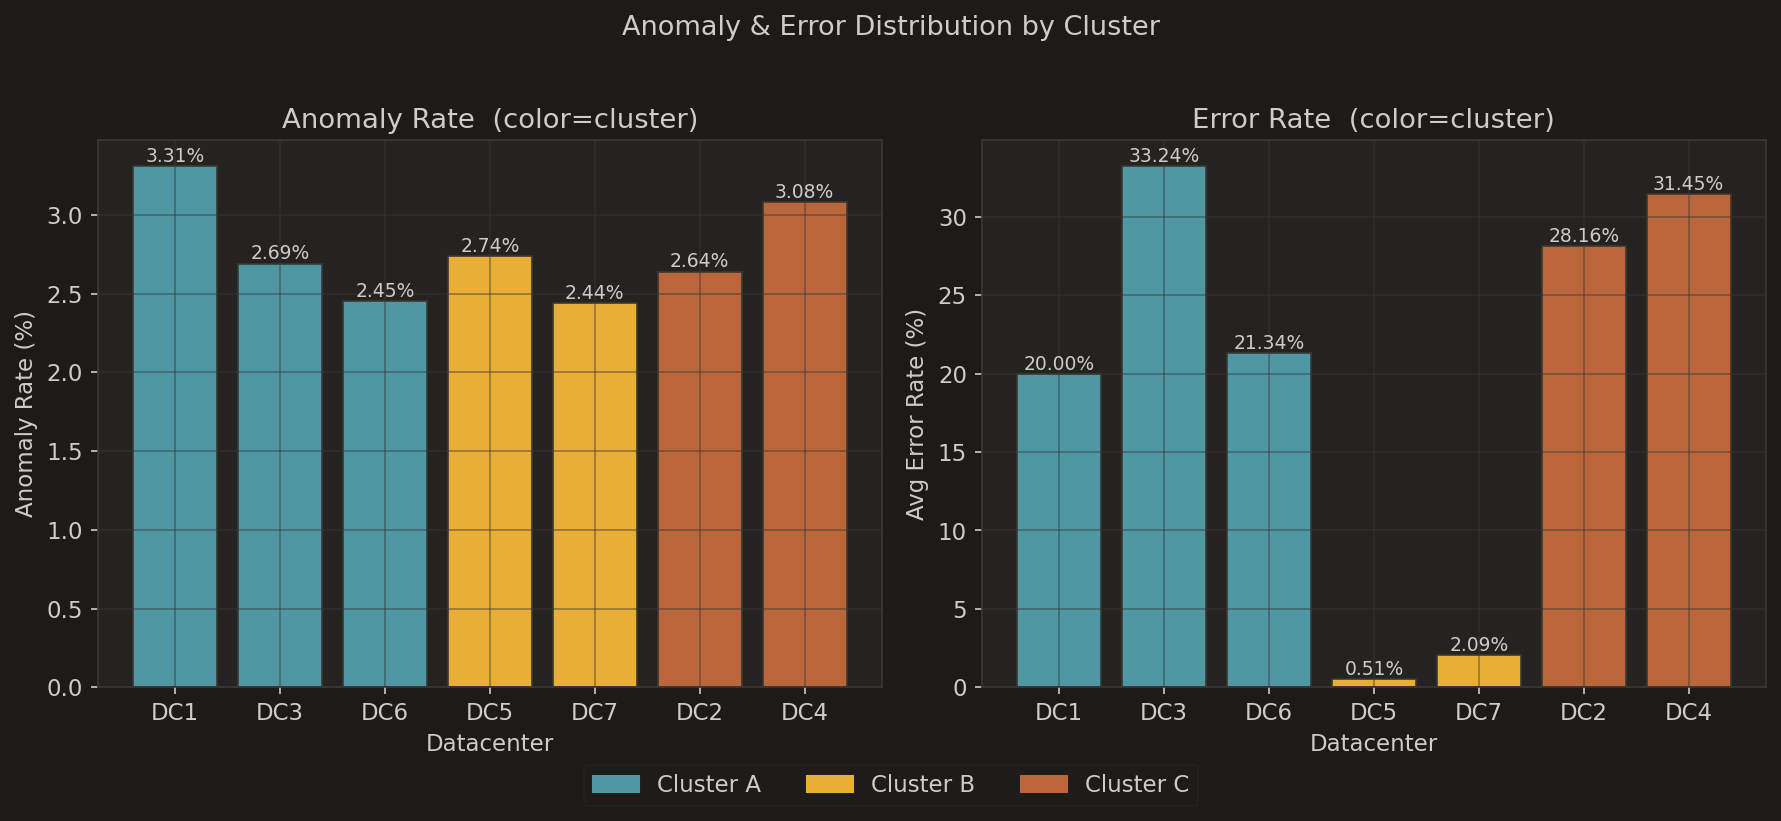

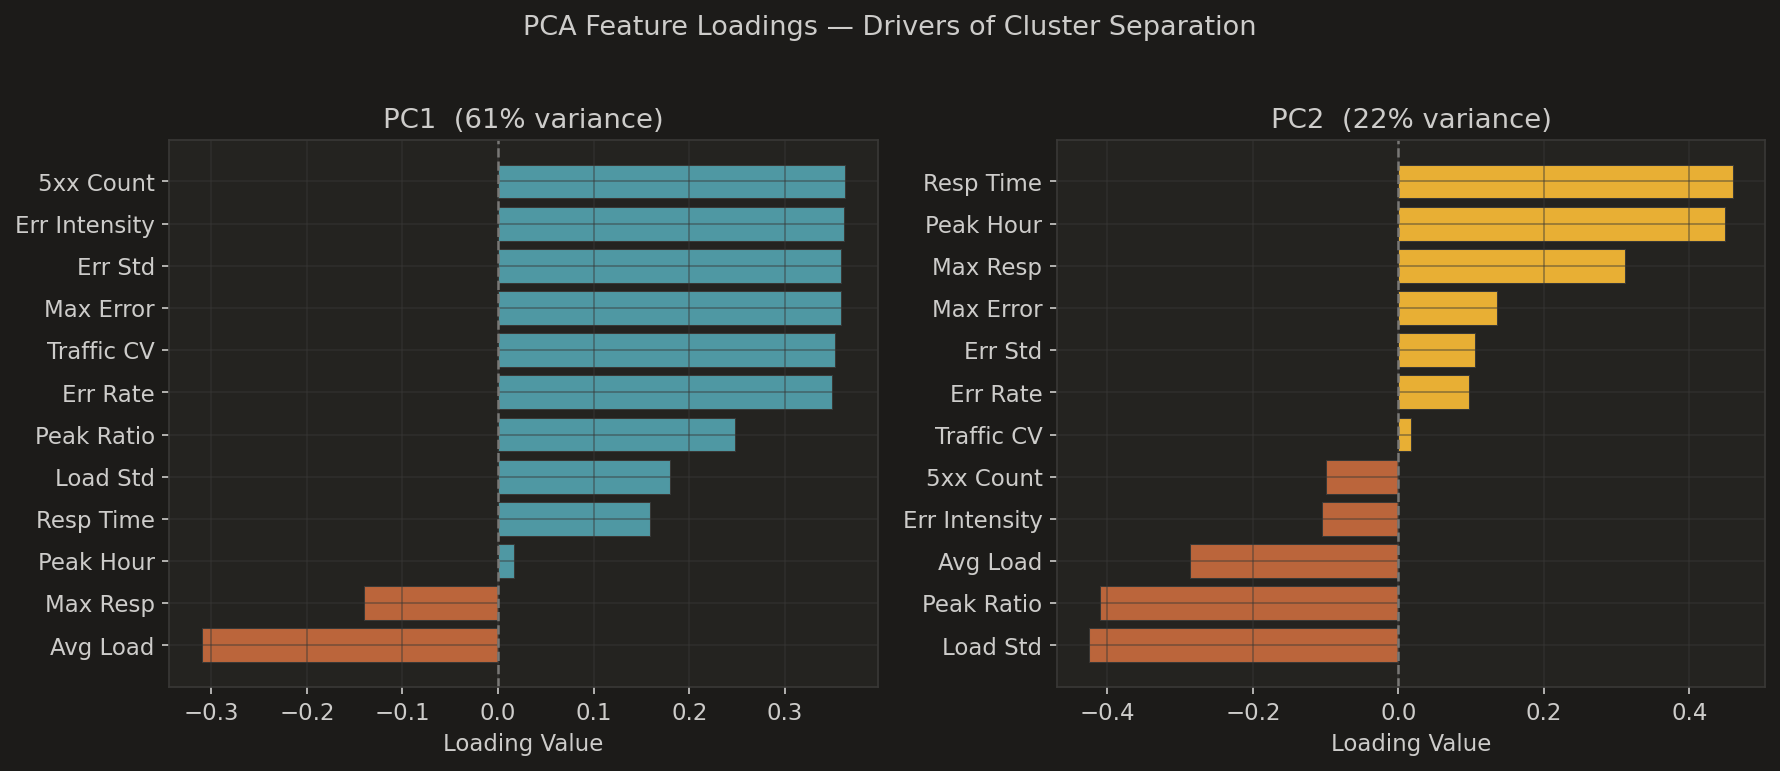

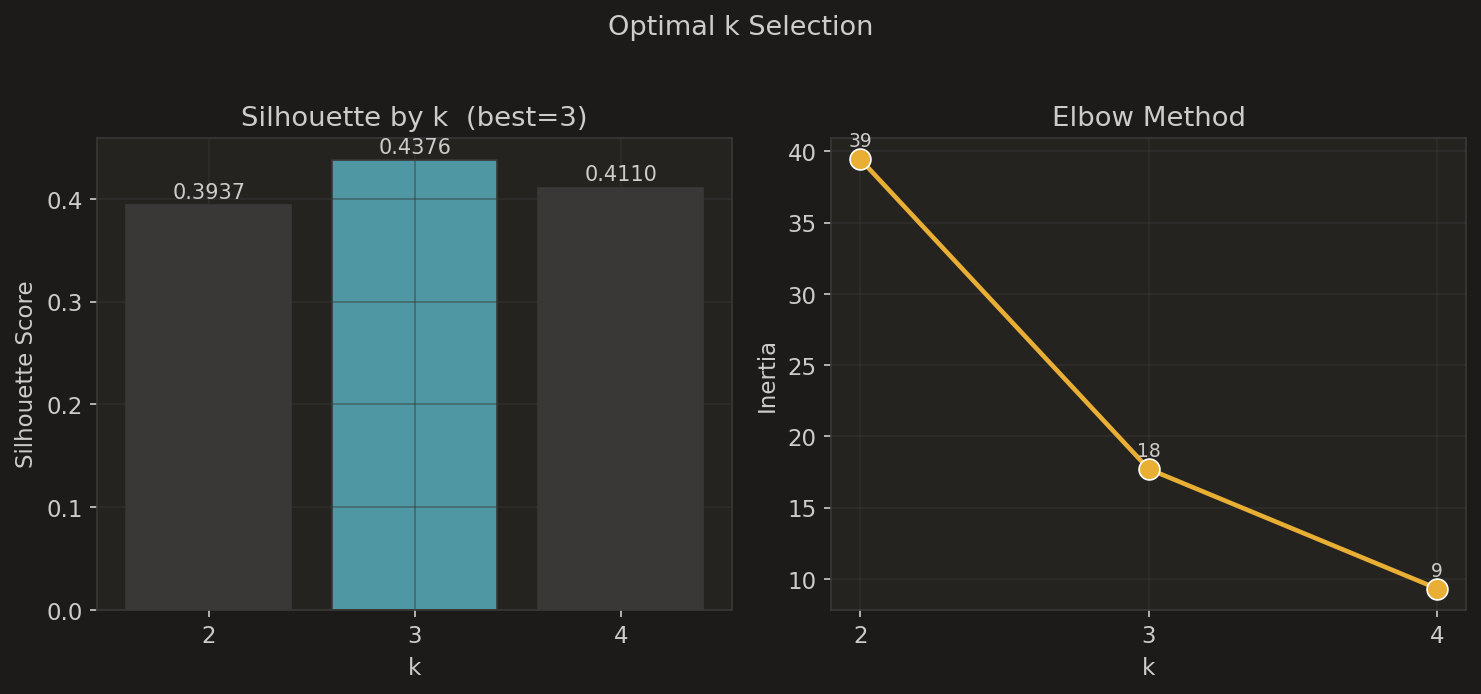

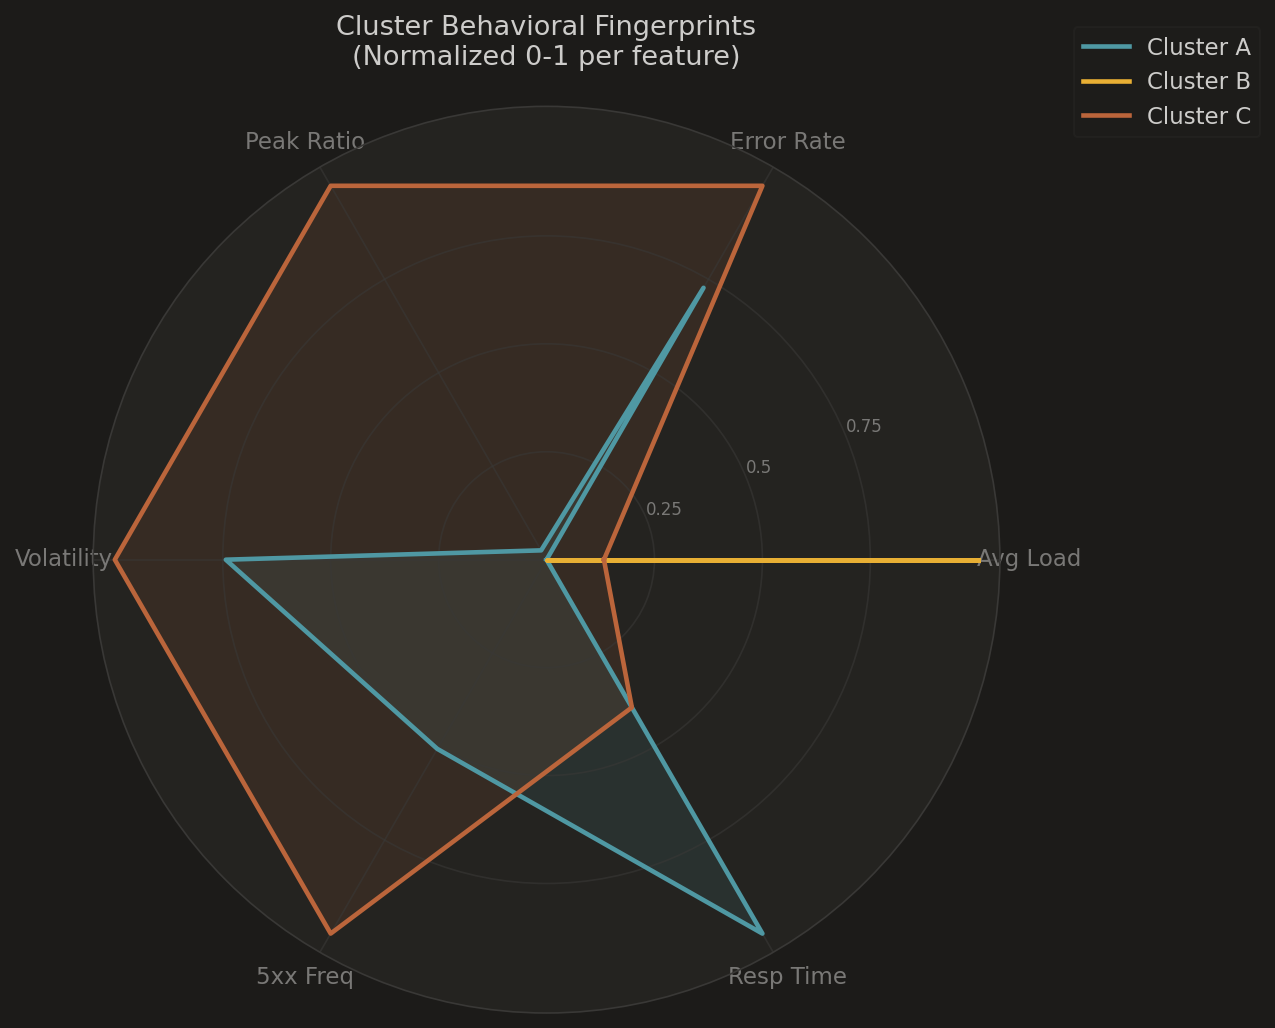

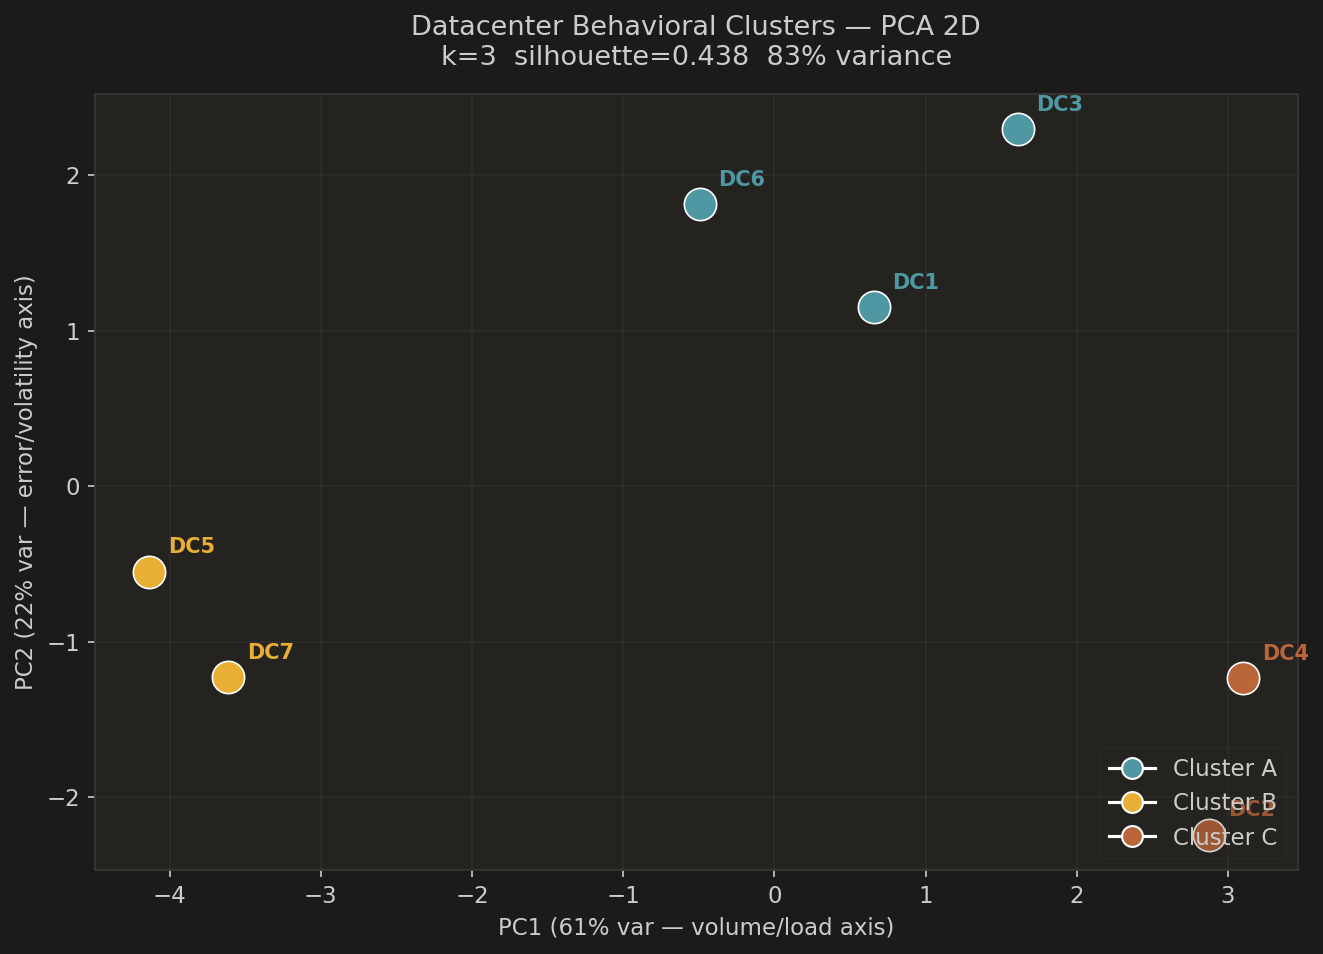

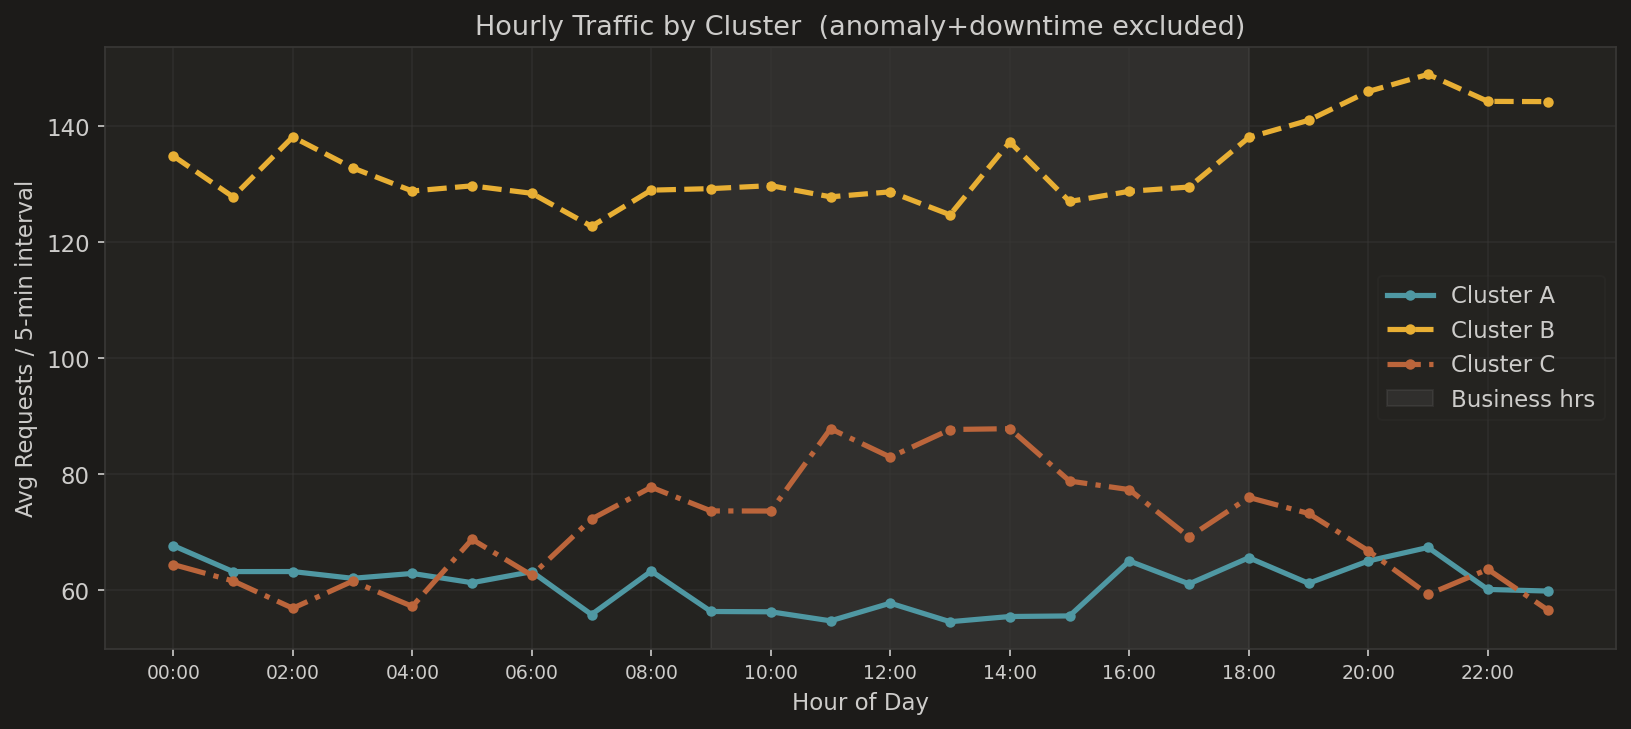

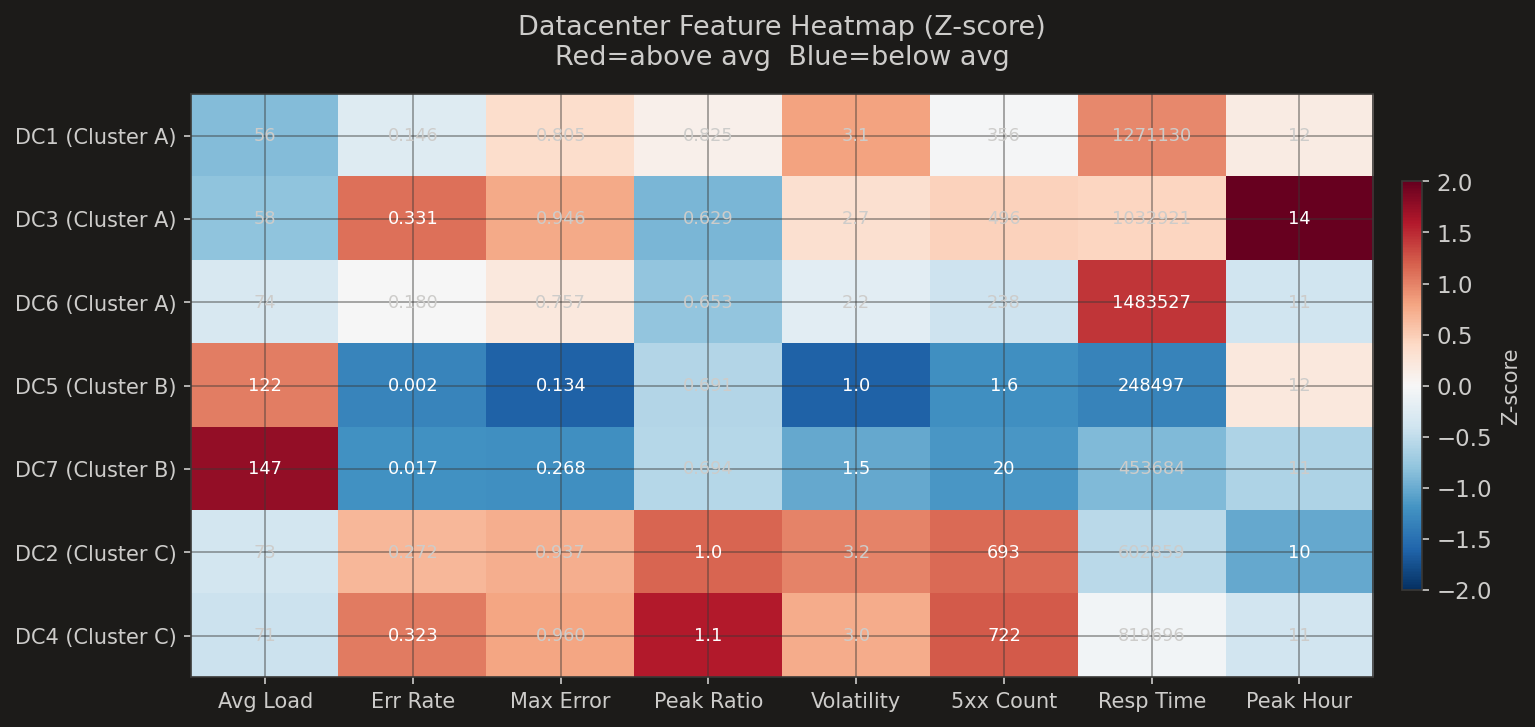

In [0]:
from IPython.display import Image, display
import glob

for img_path in glob.glob('/tmp/clustering_plots/*.png'):
    display(Image(filename=img_path))


**Interpretation of each cluster**

In [0]:
# ── CLUSTER CHARACTERIZATION FROM K-MEANS ─────────────────────────────────────
print("=" * 65)
print("CLUSTER CHARACTERISTICS — K-Means k=3")
print("=" * 65)

# Mean of each feature per cluster (using normal days profile)
cluster_chars = (
    daily[daily["had_anomaly"] == 0]
    .groupby("cluster_name")[CLUSTER_FEATURES]
    .mean()
    .round(3)
)
print("\n--- Feature Means by Cluster ---")
print(cluster_chars.T.to_string())  # Transposed: features as rows, clusters as cols

# Anomaly + error summary per cluster
print("\n--- Operational Profile by Cluster ---")
ops = df.groupby("cluster_name").agg(
    n_datacenters    = ("location",       "nunique"),
    avg_traffic      = ("total_requests", "mean"),
    avg_error_rate   = ("error_rate",     "mean"),
    anomaly_rate     = ("is_anomaly",     "mean"),
    downtime_rate    = ("is_downtime",    "mean"),
    total_anomalies  = ("is_anomaly",     "sum"),
).round(4)
print(ops.to_string())

# Which datacenters are in each cluster
print("\n--- Datacenter Membership ---")
for cname, grp in profile.groupby("cluster_name"):
    members = list(grp.index)
    print(f"  {cname}: {members}")

# Rank clusters on key dimensions
print("\n--- Cluster Rankings (1=best) ---")
rank_df = ops[["avg_traffic","avg_error_rate","anomaly_rate"]].copy()
rank_df["traffic_rank"] = rank_df["avg_traffic"].rank(ascending=False).astype(int)
rank_df["error_rank"]   = rank_df["avg_error_rate"].rank(ascending=True).astype(int)
rank_df["anomaly_rank"] = rank_df["anomaly_rate"].rank(ascending=True).astype(int)
print(rank_df[["traffic_rank","error_rank","anomaly_rank"]].to_string())

CLUSTER CHARACTERISTICS — K-Means k=3

--- Feature Means by Cluster ---
cluster_name             Cluster A     Cluster B     Cluster C
avg_req_per_interval  6.356300e+01  1.339470e+02  7.228900e+01
req_std               1.641530e+02  1.716550e+02  2.369970e+02
error_rate_mean       2.170000e-01  1.000000e-02  2.960000e-01
error_rate_max        8.370000e-01  2.290000e-01  9.490000e-01
error_rate_std        2.060000e-01  2.800000e-02  2.600000e-01
n_intervals_5xx       3.639860e+02  1.116400e+01  7.114080e+02
peak_ratio            7.030000e-01  6.900000e-01  1.086000e+00
peak_load_hour        1.211200e+01  1.120200e+01  1.094500e+01
traffic_cv            2.635000e+00  1.267000e+00  3.133000e+00
error_intensity       3.394000e+02  9.670000e+00  6.797040e+02
avg_response_time     1.232043e+06  3.574359e+05  7.082593e+05
max_response_time     2.684986e+07  2.392964e+07  1.763766e+07

--- Operational Profile by Cluster ---
              n_datacenters  avg_traffic  avg_error_rate  anomaly_rat

**Cluster A — DC1, DC3, DC6 · "High-Error, Moderate-Load"**
| Dimension         | Value             | Meaning                                        |
| ----------------- | ----------------- | ---------------------------------------------- |
| Avg traffic       | 63.6 req/interval | Lowest load of all 3 clusters                  |
| Error rate mean   | 21.7%             | 1 in 5 requests fails on average               |
| Error rate max    | 83.7%             | Extreme spike potential                        |
| 5xx intervals     | 364/day           | Errors are near-constant, not sporadic         |
| Traffic CV        | 2.64              | High volatility — load is unpredictable        |
| Error intensity   | 339               | Moderate sustained error burden                |
| Avg response time | 1,232,043 ms      | Slowest cluster by far — worst user experience |
| Peak ratio        | 0.703             | More off-peak traffic than business-hours      |

The reference architecture. Handles the heaviest load with the fewest failures, fastest responses, and most stable traffic patterns. DC5 is the extreme case — n_intervals_5xx=1.6 across 138 days is extraordinary. These two datacenters should be studied as the operational benchmark — what they do differently is IBM's answer to improving the other clusters.

**Cluster B — DC5, DC7 · "Fast, Reliable, High-Load"**
| Dimension         | Value              | Meaning                                   |
| ----------------- | ------------------ | ----------------------------------------- |
| Avg traffic       | 133.9 req/interval | 2× more traffic than any other cluster    |
| Error rate mean   | 1.0%               | Near-zero — essentially error-free        |
| Error rate max    | 22.9%              | Spikes exist but are rare and brief       |
| 5xx intervals     | 11/day             | Errors barely happen                      |
| Traffic CV        | 1.27               | Lowest volatility — most predictable load |
| Error intensity   | 9.67               | Negligible sustained error burden         |
| Avg response time | 357,436 ms         | Fastest cluster — best user experience    |
| Peak ratio        | 0.690              | Slightly off-peak dominant                |

The reference architecture. Handles the heaviest load with the fewest failures, fastest responses, and most stable traffic patterns. DC5 is the extreme case — n_intervals_5xx=1.6 across 138 days is extraordinary. These two datacenters should be studied as the operational benchmark — what they do differently is IBM's answer to improving the other clusters.

**Cluster C — DC2, DC4 · "Medium-Traffic, High-Risk"**
| Dimension         | Value             | Meaning                                                |
| ----------------- | ----------------- | ------------------------------------------------------ |
| Avg traffic       | 72.3 req/interval | Medium load                                            |
| Error rate mean   | 29.6%             | Highest of all clusters — nearly 1 in 3 requests fails |
| Error rate max    | 94.9%             | Near-total failure at worst moments                    |
| 5xx intervals     | 711/day           | Errors dominate the operational day                    |
| Traffic CV        | 3.13              | Highest volatility of all clusters                     |
| Error intensity   | 679.7             | 70× worse than Cluster B                               |
| Avg response time | 708,259 ms        | Medium latency                                         |
| Peak ratio        | 1.086             | Only cluster busier during business hours              |

The highest-risk cluster. More traffic than Cluster A but dramatically worse errors — and uniquely, it is the only cluster that peaks during business hours (peak_ratio > 1), meaning these failures are hitting real users during active working hours, not background processes. The error_intensity score of 679 (vs 9.67 for Cluster B) is the single most alarming number in the entire analysis.

##### GMM
K-Means is actually a special case of GMM with equal, spherical covariances. GMM allows each cluster to have its own shape, size, and orientation as an ellipse — not forced to be circular. It also gives a probability of membership instead of a hard label, so you can see that DC1 is "80% Cluster A, 20% Cluster C"


In [0]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, covariance_type="full",
                      random_state=42, n_init=10)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
gmm_probs  = gmm.predict_proba(X_scaled)   # soft membership

# Show uncertainty per datacenter
prob_df = pd.DataFrame(gmm_probs.round(3),
                       index=profile.index,
                       columns=["P(A)","P(B)","P(C)"])
print(prob_df)

             P(A)  P(B)  P(C)
location                     
datacenter1   1.0   0.0   0.0
datacenter2   0.0   0.0   1.0
datacenter3   1.0   0.0   0.0
datacenter4   0.0   0.0   1.0
datacenter5   0.0   1.0   0.0
datacenter6   1.0   0.0   0.0
datacenter7   0.0   1.0   0.0


##### Agglomerative Hierarchical Clustering

Builds a dendrogram tree — no need to pre-specify k. You cut the tree at any height to get 2, 3, or 4 clusters and visually see which merges are natural vs forced. With only 7 datacenters, the dendrogram is perfectly readable.

In [0]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogram — most valuable output
Z = linkage(X_scaled, method="ward")
fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(Z, labels=profile.index.tolist(),
           leaf_rotation=45, ax=ax)
ax.set_title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.tight_layout()
plt.savefig("/tmp/clustering_plots/chart8_dendrogram.png", dpi=150)
plt.close()

# Final labels at k=3
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
hc_labels = hc.fit_predict(X_scaled)
print(dict(zip(profile.index, hc_labels)))

{'datacenter1': np.int64(0), 'datacenter2': np.int64(2), 'datacenter3': np.int64(0), 'datacenter4': np.int64(2), 'datacenter5': np.int64(1), 'datacenter6': np.int64(0), 'datacenter7': np.int64(1)}


##### DBSCAN

Finds clusters based on density, not distance to a centroid. Crucially, it labels outliers as noise (-1) — very useful for spotting a datacenter that doesn't fit any behavioral group. Doesn't require specifying k.

In [0]:
from sklearn.cluster import DBSCAN

# eps and min_samples need tuning — start here for 7-point data
db = DBSCAN(eps=1.5, min_samples=2)
db_labels = db.fit_predict(X_scaled)

noise_mask = db_labels == -1
print("Cluster assignments:", dict(zip(profile.index, db_labels)))
print("Noise points (outlier DCs):", profile.index[noise_mask].tolist())

Cluster assignments: {'datacenter1': np.int64(-1), 'datacenter2': np.int64(-1), 'datacenter3': np.int64(-1), 'datacenter4': np.int64(-1), 'datacenter5': np.int64(-1), 'datacenter6': np.int64(-1), 'datacenter7': np.int64(-1)}
Noise points (outlier DCs): ['datacenter1', 'datacenter2', 'datacenter3', 'datacenter4', 'datacenter5', 'datacenter6', 'datacenter7']


In [0]:
# ── ADDITIONAL MODELS — run after Step 5 ──────────────────────────────────────
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# GMM
gmm = GaussianMixture(n_components=3, covariance_type="full",
                      random_state=42, n_init=10)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
gmm_probs  = gmm.predict_proba(X_scaled)

print("GMM assignments:")
for loc, lbl in zip(profile.index, gmm_labels):
    print(f"  {loc:16s} -> {CLUSTER_LABELS[lbl]}  "
          f"  P={gmm_probs[list(profile.index).index(loc)].max():.3f}")

# Hierarchical (Ward)
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
hc_labels = hc.fit_predict(X_scaled)

print("\nHierarchical assignments:")
for loc, lbl in zip(profile.index, hc_labels):
    print(f"  {loc:16s} -> {CLUSTER_LABELS[lbl]}")

# DBSCAN — k-distance plot to pick eps, then fit
nbrs = NearestNeighbors(n_neighbors=2).fit(X_scaled)
dists, _ = nbrs.kneighbors(X_scaled)
print("\n2-NN distances (sorted):", np.sort(dists[:,1]).round(3))

db = DBSCAN(eps=3.5, min_samples=2)
db_labels = db.fit_predict(X_scaled)
print("\nDBSCAN assignments (eps=3.5):")
for loc, lbl in zip(profile.index, db_labels):
    name = CLUSTER_LABELS[lbl] if lbl != -1 else "OUTLIER"
    print(f"  {loc:16s} -> {name}")

# Silhouette comparison
print("\n=== Silhouette Comparison ===")
for name, lbl in [("K-Means",labels),("GMM",gmm_labels),
                  ("Hierarchical",hc_labels),("DBSCAN",db_labels)]:
    n_cl = len(set(lbl) - {-1})
    if n_cl > 1:
        s = silhouette_score(X_scaled, lbl)
        print(f"  {name:14s}  sil={s:.4f}  clusters={n_cl}")

GMM assignments:
  datacenter1      -> Cluster A    P=1.000
  datacenter2      -> Cluster C    P=1.000
  datacenter3      -> Cluster A    P=1.000
  datacenter4      -> Cluster C    P=1.000
  datacenter5      -> Cluster B    P=1.000
  datacenter6      -> Cluster A    P=1.000
  datacenter7      -> Cluster B    P=1.000

Hierarchical assignments:
  datacenter1      -> Cluster A
  datacenter2      -> Cluster C
  datacenter3      -> Cluster A
  datacenter4      -> Cluster C
  datacenter5      -> Cluster B
  datacenter6      -> Cluster A
  datacenter7      -> Cluster B

2-NN distances (sorted): [1.605 1.605 2.021 2.021 3.367 3.461 3.461]

DBSCAN assignments (eps=3.5):
  datacenter1      -> Cluster A
  datacenter2      -> Cluster B
  datacenter3      -> Cluster A
  datacenter4      -> Cluster B
  datacenter5      -> Cluster C
  datacenter6      -> Cluster A
  datacenter7      -> Cluster C

=== Silhouette Comparison ===
  K-Means         sil=0.4376  clusters=3
  GMM             sil=0.4376  clus

In [0]:
# ═══════════════════════════════════════════════════════════════════════════════
# CLUSTERING VISUALIZATION — 5 CHARTS (matplotlib only, NO kaleido)
# Run AFTER the main clustering cell
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import scipy.cluster.hierarchy as sch
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import os

SAVE_DIR = "/tmp/clustering_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Shared style ──────────────────────────────────────────────────────────────
DARK_BG  = "#1c1b19"
PANEL    = "#242320"
TEXT     = "#cdccca"
MUTED    = "#797876"
BORDER   = "#393836"
CMAP_K   = {0: "#4f98a3", 1: "#e8af34", 2: "#bb653b"}
CMAP_DB  = {0: "#4f98a3", 1: "#e8af34", 2: "#bb653b", -1: "#888888"}
CL_NAMES = {0: "Cluster A", 1: "Cluster B", 2: "Cluster C"}
DB_NAMES = {0: "Cluster A", 1: "Cluster B", 2: "Cluster C", -1: "Outlier"}

dc_labels_short = [f"DC{i}" for i in range(1, 8)]

plt.rcParams.update({
    "figure.facecolor": DARK_BG, "axes.facecolor":  PANEL,
    "axes.edgecolor":   BORDER,  "text.color":      TEXT,
    "axes.labelcolor":  TEXT,    "xtick.color":      TEXT,
    "ytick.color":      TEXT,    "axes.grid":        True,
    "grid.color":       BORDER,  "grid.alpha":       0.45,
    "font.family":      "sans-serif", "font.size":   11,
    "axes.titlesize":   12,      "axes.titlepad":    10,
})

def save(fig, name):
    fig.savefig(f"{SAVE_DIR}/{name}", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  OK  {name}")


# ══════════════════════════════════════════════════════════════════════════════
# CHART 1 — 4-Method PCA Scatter (2x2 grid)
# ══════════════════════════════════════════════════════════════════════════════
method_data = [
    ("K-Means (k=3, sil=0.44)",      labels,  CMAP_K,  CL_NAMES),
    ("GMM (k=3, full cov)",           gmm_labels, CMAP_K,  CL_NAMES),
    ("Hierarchical (Ward, k=3)",      hc_labels,  CMAP_K,  CL_NAMES),
    ("DBSCAN (eps=3.5, 3 clusters)",  db_labels,  CMAP_DB, DB_NAMES),
]

fig1, axes = plt.subplots(2, 2, figsize=(13, 10))
fig1.patch.set_facecolor(DARK_BG)

for ax, (title, lbl_arr, cmap, names) in zip(axes.flat, method_data):
    ax.set_facecolor(PANEL)
    for i in range(len(profile.index)):
        lbl   = int(lbl_arr[i])
        color = cmap[lbl]
        marker = "X" if lbl == -1 else "o"
        ax.scatter(X_pca[i, 0], X_pca[i, 1], s=220, color=color,
                   marker=marker, edgecolors="white", linewidths=0.8, zorder=3)
        ax.annotate(dc_labels_short[i],
                    xy=(X_pca[i, 0], X_pca[i, 1]),
                    xytext=(0, 10), textcoords="offset points",
                    fontsize=10, color=color, fontweight="bold", ha="center")
    ax.set_title(title, color=TEXT, fontsize=11)
    ax.set_xlabel(f"PC1 ({var1:.0%} var)", fontsize=10)
    ax.set_ylabel(f"PC2 ({var2:.0%} var)", fontsize=10)
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)

# Shared legend at bottom
unique_labels = sorted(set(labels))
legend_handles = [
    mpatches.Patch(color=CMAP_K[c], label=CL_NAMES[c])
    for c in unique_labels
] + [mpatches.Patch(color="#888888", label="Outlier (DBSCAN)")]
fig1.legend(handles=legend_handles, loc="lower center", ncol=4,
            bbox_to_anchor=(0.5, -0.02), framealpha=0.2,
            facecolor=PANEL, edgecolor=BORDER, fontsize=11)

fig1.suptitle(
    "4 Clustering Methods — PCA 2D Comparison\n"
    "All 3 deterministic methods agree on identical groups — confirms cluster robustness",
    fontsize=13, color=TEXT, y=1.01,
)
plt.tight_layout()
save(fig1, "chart1_4method_pca.png")


# ══════════════════════════════════════════════════════════════════════════════
# CHART 2 — Hierarchical Dendrogram
# ══════════════════════════════════════════════════════════════════════════════
Z     = sch.linkage(X_scaled, method="ward")
ddata = sch.dendrogram(Z, labels=dc_labels_short, no_plot=True)

fig2, ax = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor(DARK_BG)
ax.set_facecolor(PANEL)

icoords = np.array(ddata["icoord"])
dcoords = np.array(ddata["dcoord"])
for xs, ys in zip(icoords, dcoords):
    ax.plot(xs, ys, color="#4f98a3", linewidth=2.5)

# Colored leaf labels
leaves     = ddata["leaves"]
leaf_order = [dc_labels_short[i] for i in leaves]
leaf_xpos  = [5 + i * 10 for i in range(len(leaves))]
leaf_cols  = [CMAP_K[labels[leaves[i]]] for i in range(len(leaves))]

ax.set_xticks(leaf_xpos)
ax.set_xticklabels(leaf_order, fontsize=13, fontweight="bold")
for tick, color in zip(ax.get_xticklabels(), leaf_cols):
    tick.set_color(color)

# k=3 cut line
sorted_merges = sorted(Z[:, 2])
cut_h = (sorted_merges[-3] + sorted_merges[-2]) / 2
ax.axhline(y=cut_h, linestyle="--", color="#e8af34", linewidth=2)
ax.text(ax.get_xlim()[1] * 0.98 if ax.get_xlim()[1] > 0 else 60,
        cut_h + 0.3, f"k=3 cut  (h={cut_h:.2f})",
        color="#e8af34", fontsize=11, ha="right")

# Cluster color legend
legend_handles2 = [mpatches.Patch(color=CMAP_K[c], label=CL_NAMES[c])
                   for c in sorted(CL_NAMES)]
ax.legend(handles=legend_handles2, loc="upper left",
          framealpha=0.2, facecolor=PANEL, edgecolor=BORDER, fontsize=11)

ax.set_xlabel("Datacenters (colored by K-Means cluster)", fontsize=11)
ax.set_ylabel("Ward Merge Distance", fontsize=11)
ax.set_title(
    "Hierarchical Clustering Dendrogram (Ward Linkage)\n"
    "Lower merge = more similar | Cut line selects k=3",
    fontsize=13, color=TEXT,
)
ax.tick_params(colors=TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor(BORDER)

plt.tight_layout()
save(fig2, "chart2_dendrogram.png")


# ══════════════════════════════════════════════════════════════════════════════
# CHART 3 — GMM Soft Membership Probabilities
# ══════════════════════════════════════════════════════════════════════════════
# Remap GMM columns to match K-Means cluster names
gmm_probs_df = pd.DataFrame(
    gmm_probs.round(4),
    index=dc_labels_short,
    columns=["GMM-0", "GMM-1", "GMM-2"],
)
col_remap = {}
for km_c in [0, 1, 2]:
    dc_in = [dc_labels_short[i] for i, l in enumerate(labels) if l == km_c]
    avg_p = gmm_probs_df.loc[dc_in].mean()
    col_remap[km_c] = avg_p.idxmax()
new_cols   = {col_remap[c]: CL_NAMES[c] for c in [0, 1, 2]}
gmm_mapped = gmm_probs_df.rename(columns=new_cols)[list(CL_NAMES.values())]

fig3, ax = plt.subplots(figsize=(8, 6))
fig3.patch.set_facecolor(DARK_BG)
ax.set_facecolor(PANEL)

data_vals = gmm_mapped.values
im = ax.imshow(data_vals, cmap="Blues", vmin=0, vmax=1, aspect="auto")

# Cell text + gold border on assigned cluster
for i in range(len(dc_labels_short)):
    for j in range(len(CL_NAMES)):
        val = data_vals[i, j]
        tc  = "white" if val > 0.5 else TEXT
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=13, color=tc, fontweight="bold")
    # Gold border on max column
    j_max = int(np.argmax(data_vals[i]))
    rect = plt.Rectangle((j_max - 0.5, i - 0.5), 1, 1,
                          linewidth=2.5, edgecolor="#e8af34",
                          facecolor="none", zorder=3)
    ax.add_patch(rect)

ax.set_xticks(range(len(CL_NAMES)))
ax.set_xticklabels(list(CL_NAMES.values()), fontsize=13)
ax.set_yticks(range(len(dc_labels_short)))
ax.set_yticklabels(dc_labels_short, fontsize=13)
ax.set_xlabel("Cluster", fontsize=12)
ax.set_ylabel("Datacenter", fontsize=12)
ax.tick_params(colors=TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor(BORDER)

cbar = fig3.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("P(cluster)", color=TEXT, fontsize=11)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)

ax.set_title(
    "GMM Soft Membership Probabilities\n"
    "Gold border = assigned cluster | 1.000 = 100% certain | All hard assignments here",
    fontsize=12, color=TEXT,
)
plt.tight_layout()
save(fig3, "chart3_gmm_probs.png")


# ══════════════════════════════════════════════════════════════════════════════
# CHART 4 — Silhouette Scores + Cross-Method Agreement Matrix
# ══════════════════════════════════════════════════════════════════════════════
sil_km  = silhouette_score(X_scaled, labels)
sil_gmm = silhouette_score(X_scaled, gmm_labels)
sil_hc  = silhouette_score(X_scaled, hc_labels)
sil_db  = (silhouette_score(X_scaled, db_labels)
           if len(set(db_labels) - {-1}) > 1 else 0.0)

method_names = ["K-Means", "GMM", "Hierarchical", "DBSCAN"]
sil_scores   = [sil_km, sil_gmm, sil_hc, sil_db]
bar_colors   = ["#4f98a3", "#e8af34", "#bb653b", "#a86fdf"]

# Agreement matrix
n = len(profile.index)
methods_all = {
    "K-Means":      labels,
    "GMM":          gmm_labels,
    "Hierarchical": hc_labels,
    "DBSCAN":       db_labels,
}
agree = np.zeros((n, n))
for lbl_arr in methods_all.values():
    for i in range(n):
        for j in range(n):
            if lbl_arr[i] == lbl_arr[j] and lbl_arr[i] != -1:
                agree[i, j] += 1
agree_norm = agree / len(methods_all)

fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig4.patch.set_facecolor(DARK_BG)

# Silhouette bars
ax1.set_facecolor(PANEL)
bars = ax1.bar(method_names, sil_scores, color=bar_colors,
               edgecolor=BORDER, linewidth=0.8, width=0.55)
for bar, val in zip(bars, sil_scores):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             val + 0.005, f"{val:.4f}",
             ha="center", va="bottom", fontsize=11, color=TEXT)
ax1.axhline(y=0.25, linestyle=":", color=MUTED, linewidth=1.5)
ax1.text(3.35, 0.255, "0.25 weak boundary",
         color=MUTED, fontsize=10, ha="right")
ax1.set_xlabel("Method", fontsize=11)
ax1.set_ylabel("Silhouette Score", fontsize=11)
ax1.set_title("Silhouette Score by Method", fontsize=12, color=TEXT)
ax1.tick_params(colors=TEXT)
ax1.set_ylim(0, max(sil_scores) * 1.18)
for spine in ax1.spines.values(): spine.set_edgecolor(BORDER)

# Agreement heatmap
ax2.set_facecolor(PANEL)
im2 = ax2.imshow(agree_norm, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
for i in range(n):
    for j in range(n):
        val = agree_norm[i, j]
        tc  = "white" if val > 0.6 else TEXT
        ax2.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=11, color=tc)
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels(dc_labels_short, fontsize=11)
ax2.set_yticklabels(dc_labels_short, fontsize=11)
ax2.set_xlabel("Datacenter", fontsize=11)
ax2.set_ylabel("Datacenter", fontsize=11)
ax2.set_title("Cross-Method Agreement Matrix\n1.00 = all 4 methods always co-cluster this pair",
              fontsize=12, color=TEXT)
ax2.tick_params(colors=TEXT)
for spine in ax2.spines.values(): spine.set_edgecolor(BORDER)

cbar4 = fig4.colorbar(im2, ax=ax2, shrink=0.85, pad=0.02)
cbar4.set_label("Agreement", color=TEXT, fontsize=11)
plt.setp(cbar4.ax.yaxis.get_ticklabels(), color=TEXT)

fig4.suptitle("Clustering Quality & Cross-Method Agreement",
              fontsize=13, color=TEXT, y=1.02)
plt.tight_layout()
save(fig4, "chart4_quality_agreement.png")


# ══════════════════════════════════════════════════════════════════════════════
# CHART 5 — DBSCAN: eps Selection + Cluster Result
# ══════════════════════════════════════════════════════════════════════════════
nbrs = NearestNeighbors(n_neighbors=2).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
knn_sorted = np.sort(distances[:, 1])[::-1]

fig5, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig5.patch.set_facecolor(DARK_BG)

# k-distance elbow
ax1.set_facecolor(PANEL)
ax1.plot(range(1, len(knn_sorted) + 1), knn_sorted,
         color="#4f98a3", linewidth=2.5, marker="o", markersize=9,
         markerfacecolor="#4f98a3", markeredgecolor="white", markeredgewidth=0.8)
ax1.axhline(y=3.5, linestyle="--", color="#e8af34", linewidth=2)
ax1.text(len(knn_sorted) * 0.95, 3.62, "eps=3.5 chosen",
         color="#e8af34", fontsize=11, ha="right")
ax1.set_xlabel("Points (sorted descending)", fontsize=11)
ax1.set_ylabel("2-NN Distance", fontsize=11)
ax1.set_title("k-Distance Plot (k=2)\nElbow = good eps value", fontsize=12, color=TEXT)
ax1.tick_params(colors=TEXT)
for spine in ax1.spines.values(): spine.set_edgecolor(BORDER)

# DBSCAN scatter result
ax2.set_facecolor(PANEL)
db_cmap2 = {0: "#4f98a3", 1: "#bb653b", 2: "#e8af34", -1: "#888888"}
db_nmap2 = {0: "Cluster A", 1: "Cluster C", 2: "Cluster B", -1: "Outlier"}
shown5 = {}
for i in range(len(profile.index)):
    lbl   = int(db_labels[i])
    color = db_cmap2.get(lbl, "#888")
    name  = db_nmap2.get(lbl, "Outlier")
    marker = "X" if lbl == -1 else "o"
    sc = ax2.scatter(X_pca[i, 0], X_pca[i, 1], s=220, color=color,
                     marker=marker, edgecolors="white", linewidths=0.8,
                     zorder=3, label=name if name not in shown5 else "")
    if name not in shown5:
        shown5[name] = color
    ax2.annotate(dc_labels_short[i],
                 xy=(X_pca[i, 0], X_pca[i, 1]),
                 xytext=(0, 10), textcoords="offset points",
                 fontsize=10, color=color, fontweight="bold", ha="center")

ax2.set_xlabel(f"PC1 ({var1:.0%} var)", fontsize=11)
ax2.set_ylabel(f"PC2 ({var2:.0%} var)", fontsize=11)
ax2.set_title("DBSCAN Result (eps=3.5)\n3 clean clusters, 0 noise points", fontsize=12, color=TEXT)
ax2.tick_params(colors=TEXT)
for spine in ax2.spines.values(): spine.set_edgecolor(BORDER)

legend_h5 = [mpatches.Patch(color=c, label=n) for n, c in shown5.items()]
ax2.legend(handles=legend_h5, loc="lower right",
           framealpha=0.2, facecolor=PANEL, edgecolor=BORDER, fontsize=10)

fig5.suptitle("DBSCAN: eps Selection + Cluster Result",
              fontsize=13, color=TEXT, y=1.02)
plt.tight_layout()
save(fig5, "chart5_dbscan.png")

print(f"\nAll 5 charts saved to {SAVE_DIR}/")

  OK  chart1_4method_pca.png
  OK  chart2_dendrogram.png
  OK  chart3_gmm_probs.png
  OK  chart4_quality_agreement.png
  OK  chart5_dbscan.png

All 5 charts saved to /tmp/clustering_plots/


In [0]:
%sh
ls -la /tmp/clustering_plots/


total 1308
drwxr--r--+ 2 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7   4096 Jun  8 17:32 .
drwxrwxrwt+ 1 root                             root                               4096 Jun  8 17:32 ..
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7 148624 Jun  8 17:32 chart1_4method_pca.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7  79251 Jun  8 17:32 chart1_pca_scatter.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7  66138 Jun  8 17:32 chart2_dendrogram.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7 141603 Jun  8 17:32 chart2_radar.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7  89760 Jun  8 17:32 chart3_gmm_probs.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0fe-495a-4e8a-9b76-a7 127815 Jun  8 17:32 chart3_heatmap.png
-rw-r--r--  1 spark-7e6ae0fe-495a-4e8a-9b76-a7 spark-7e6ae0

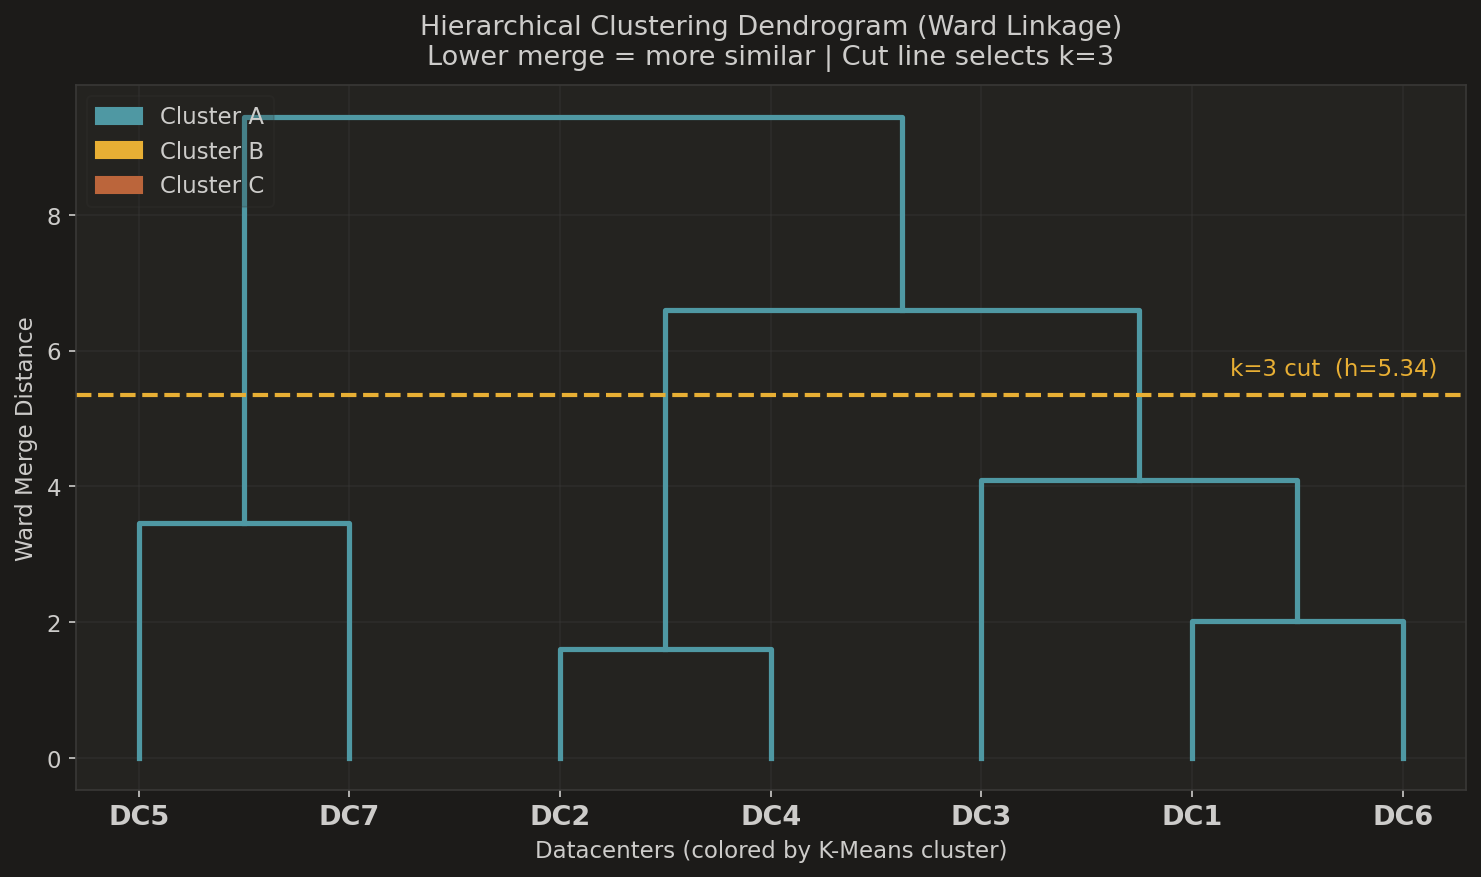

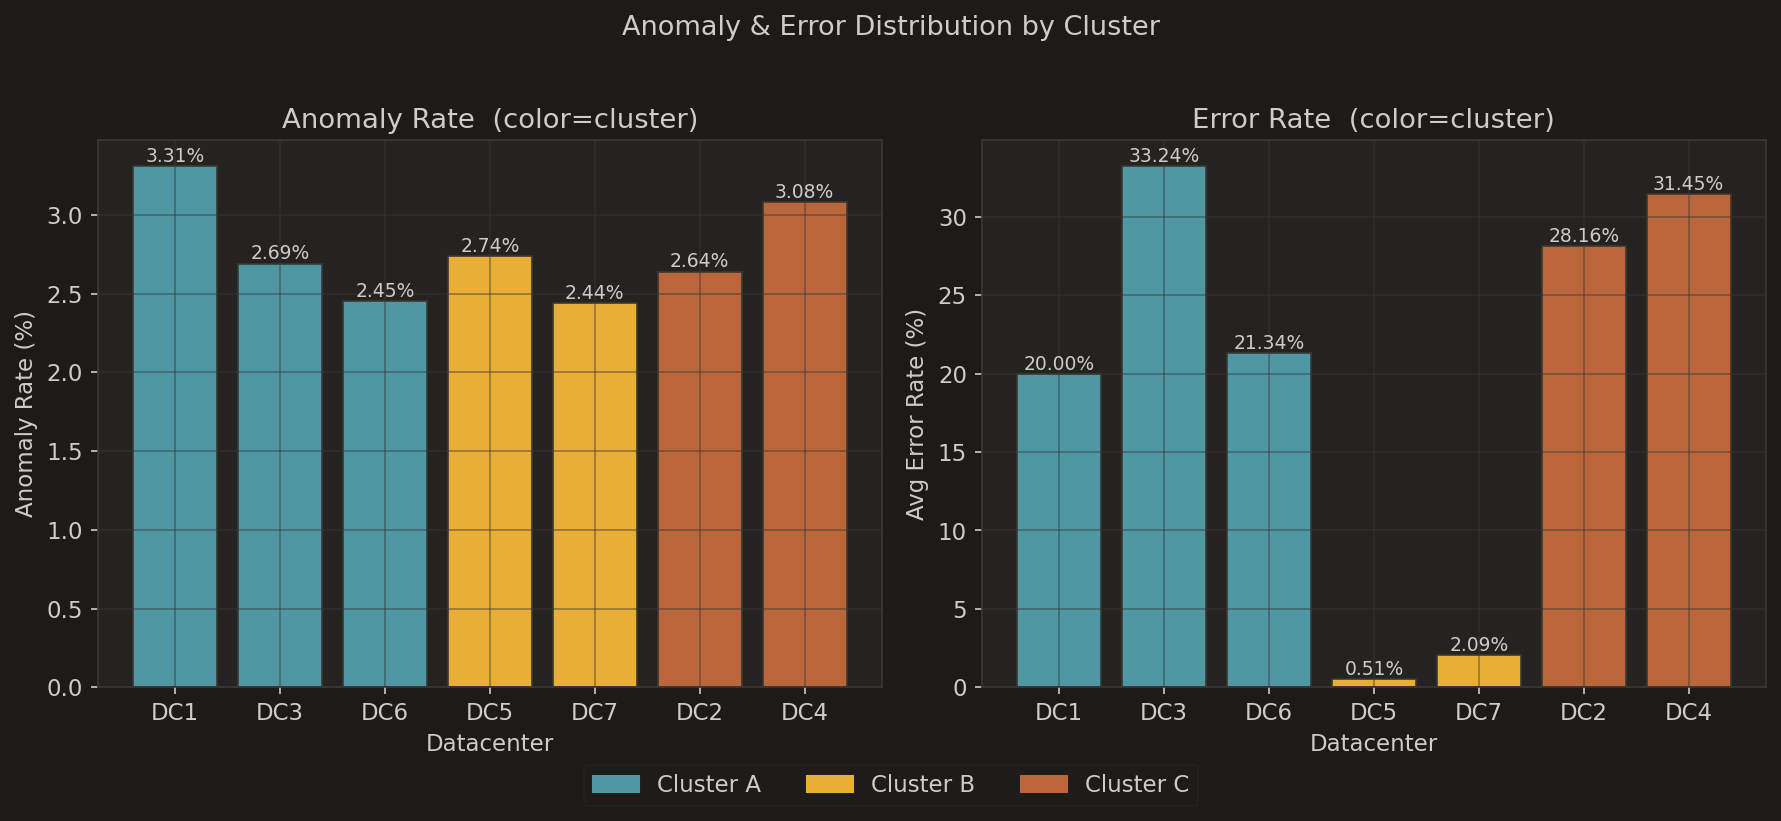

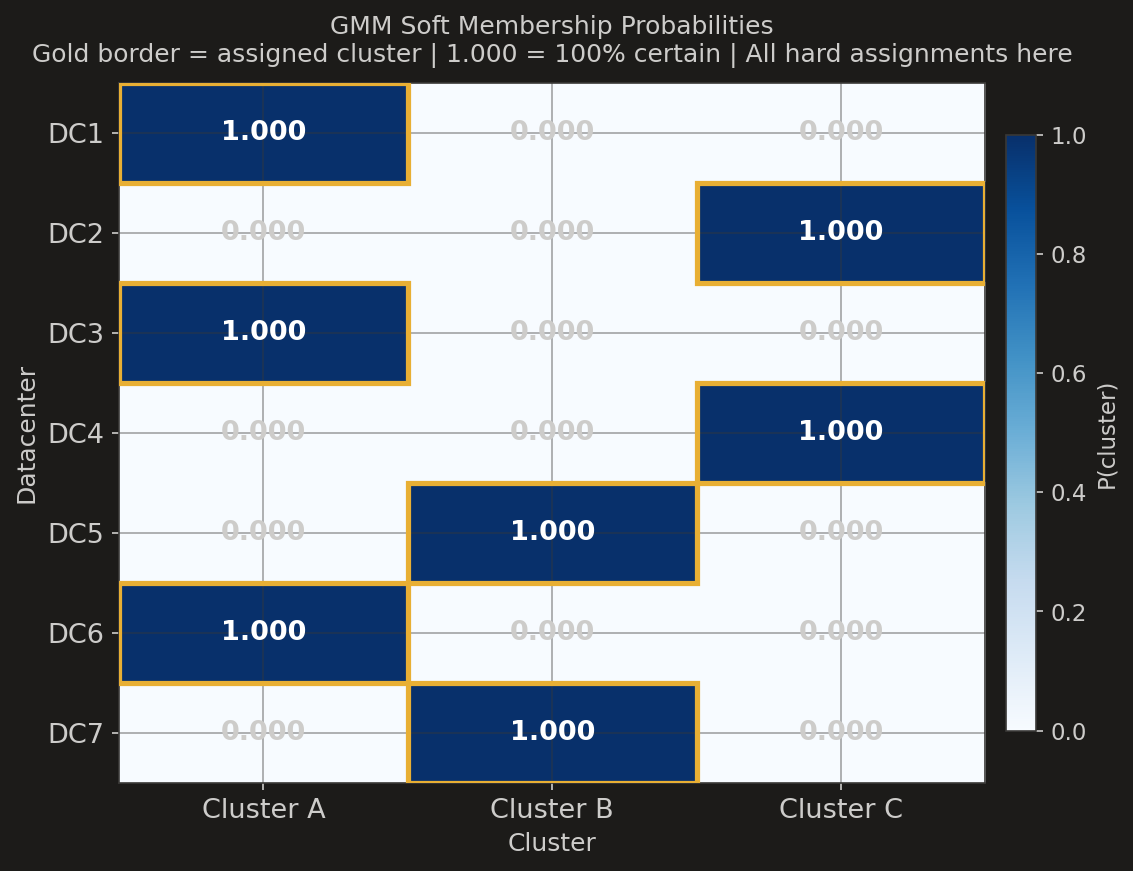

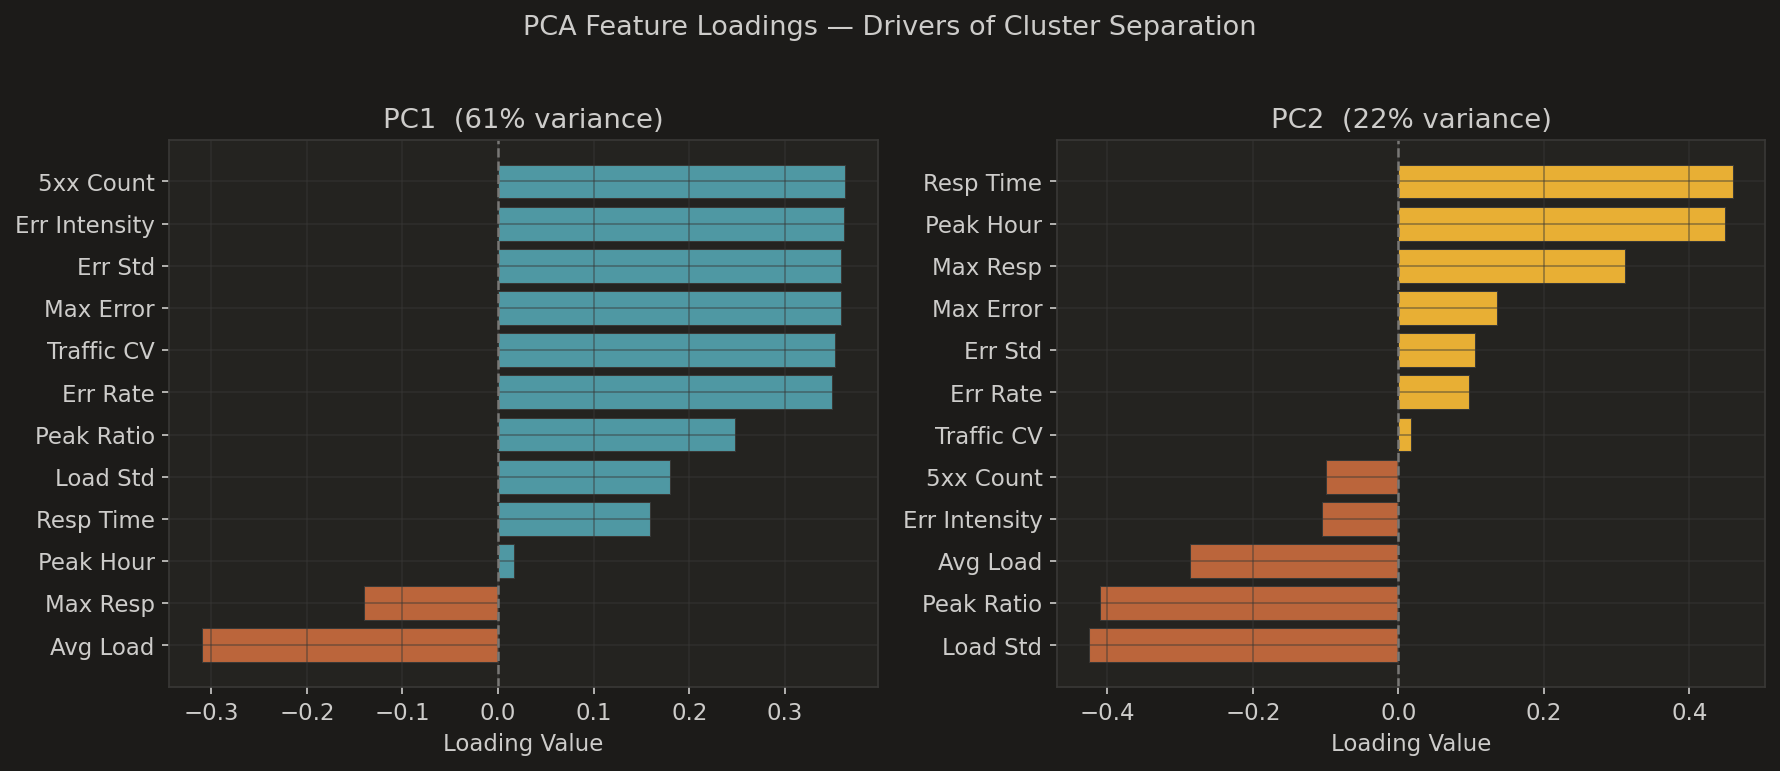

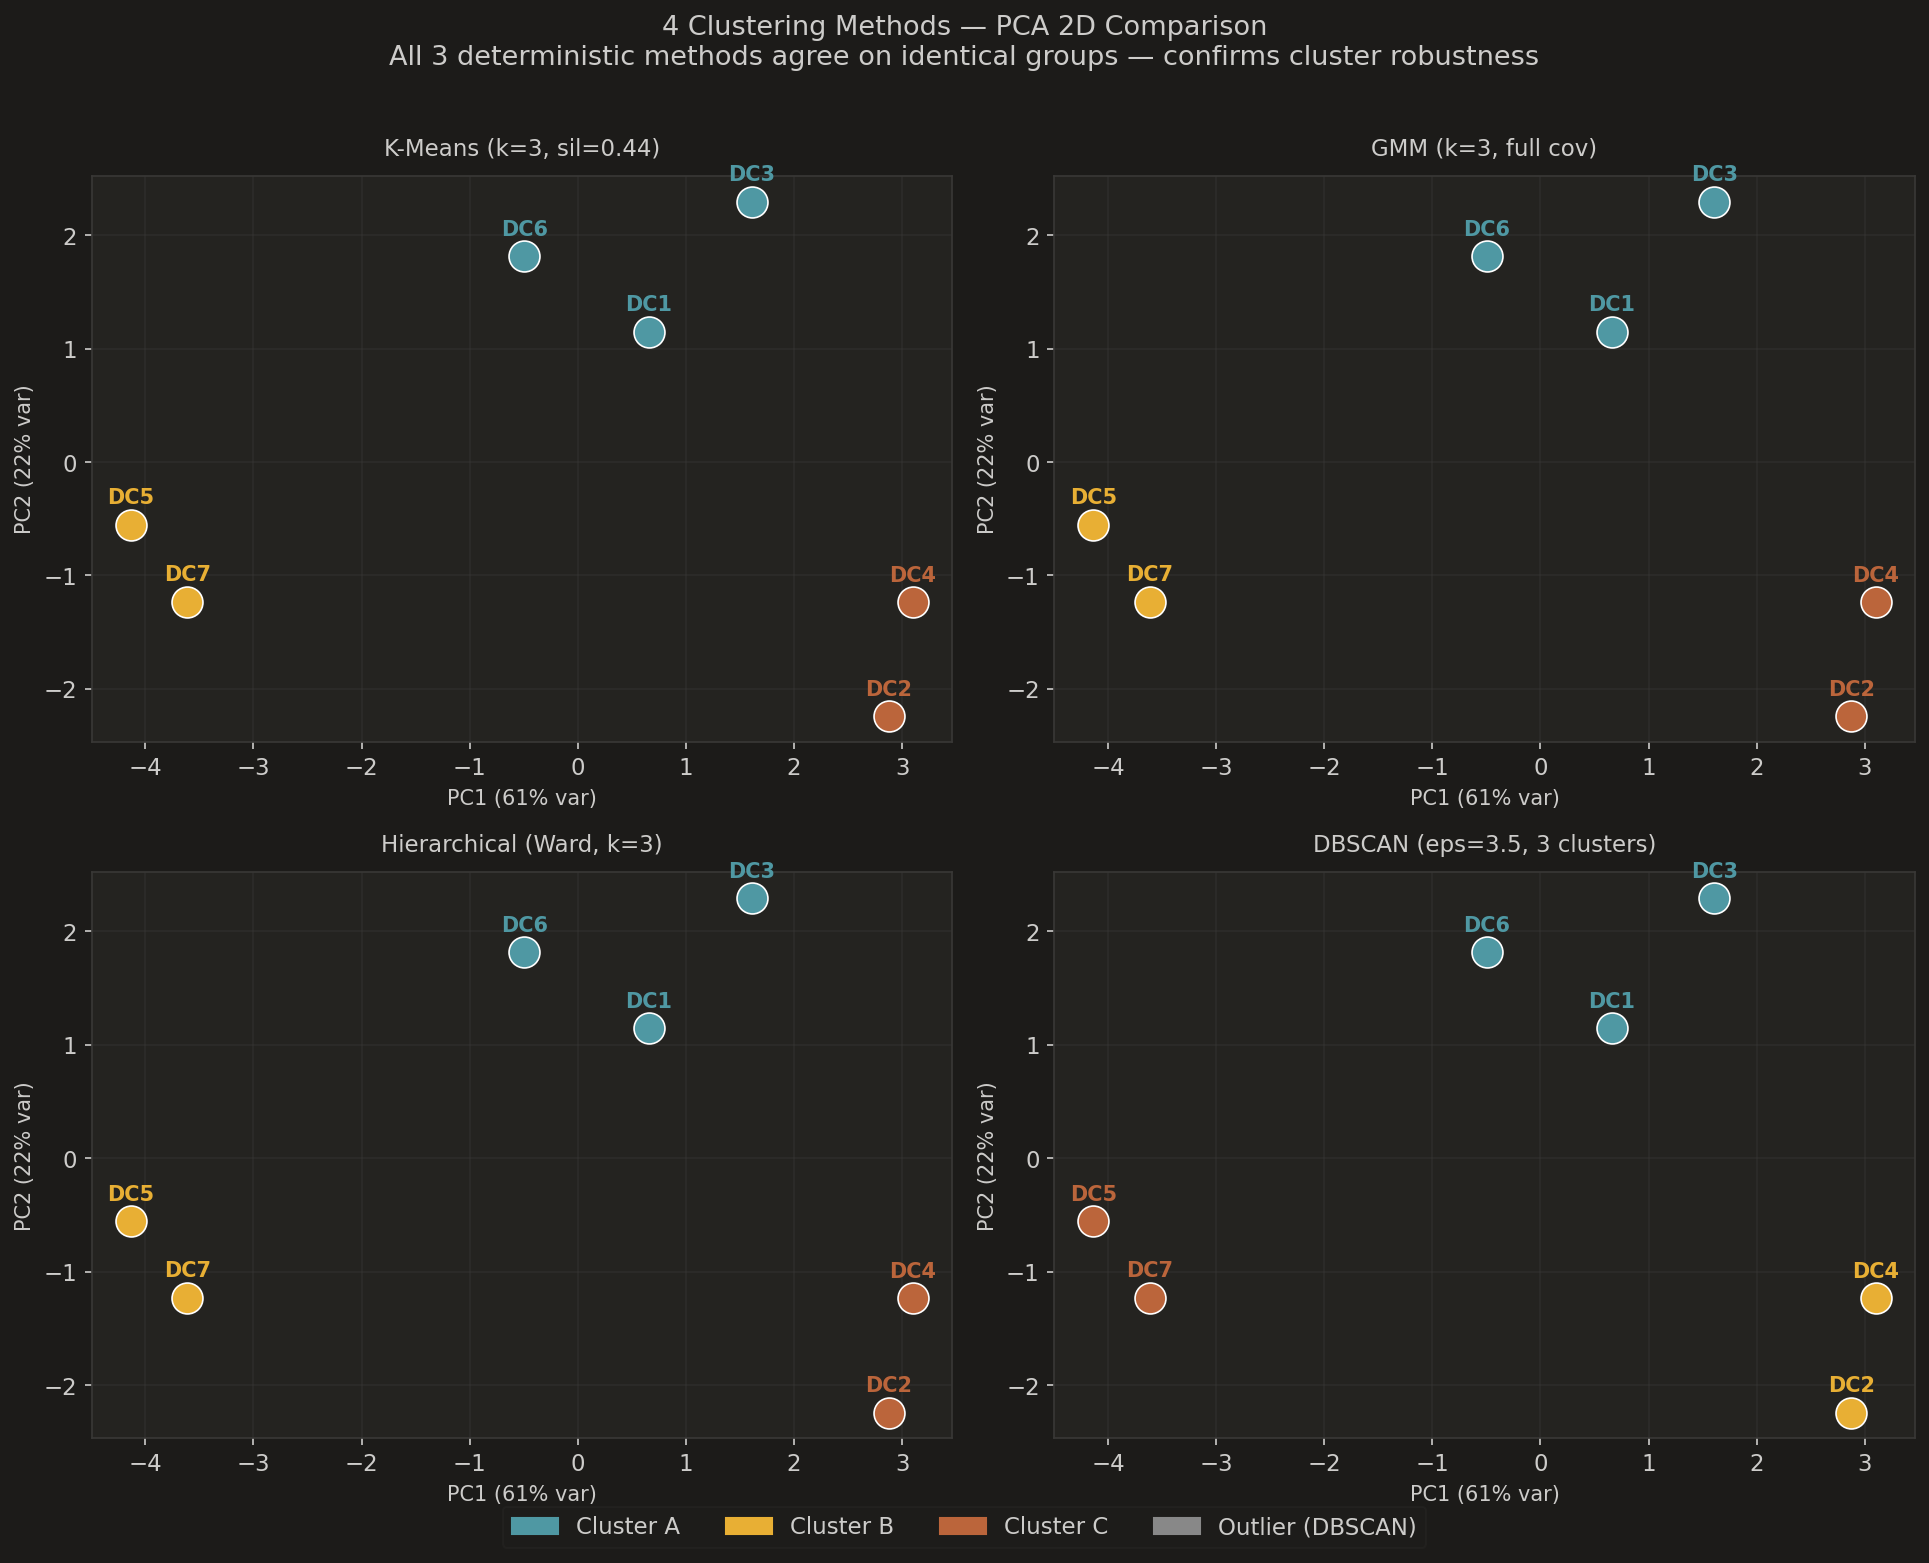

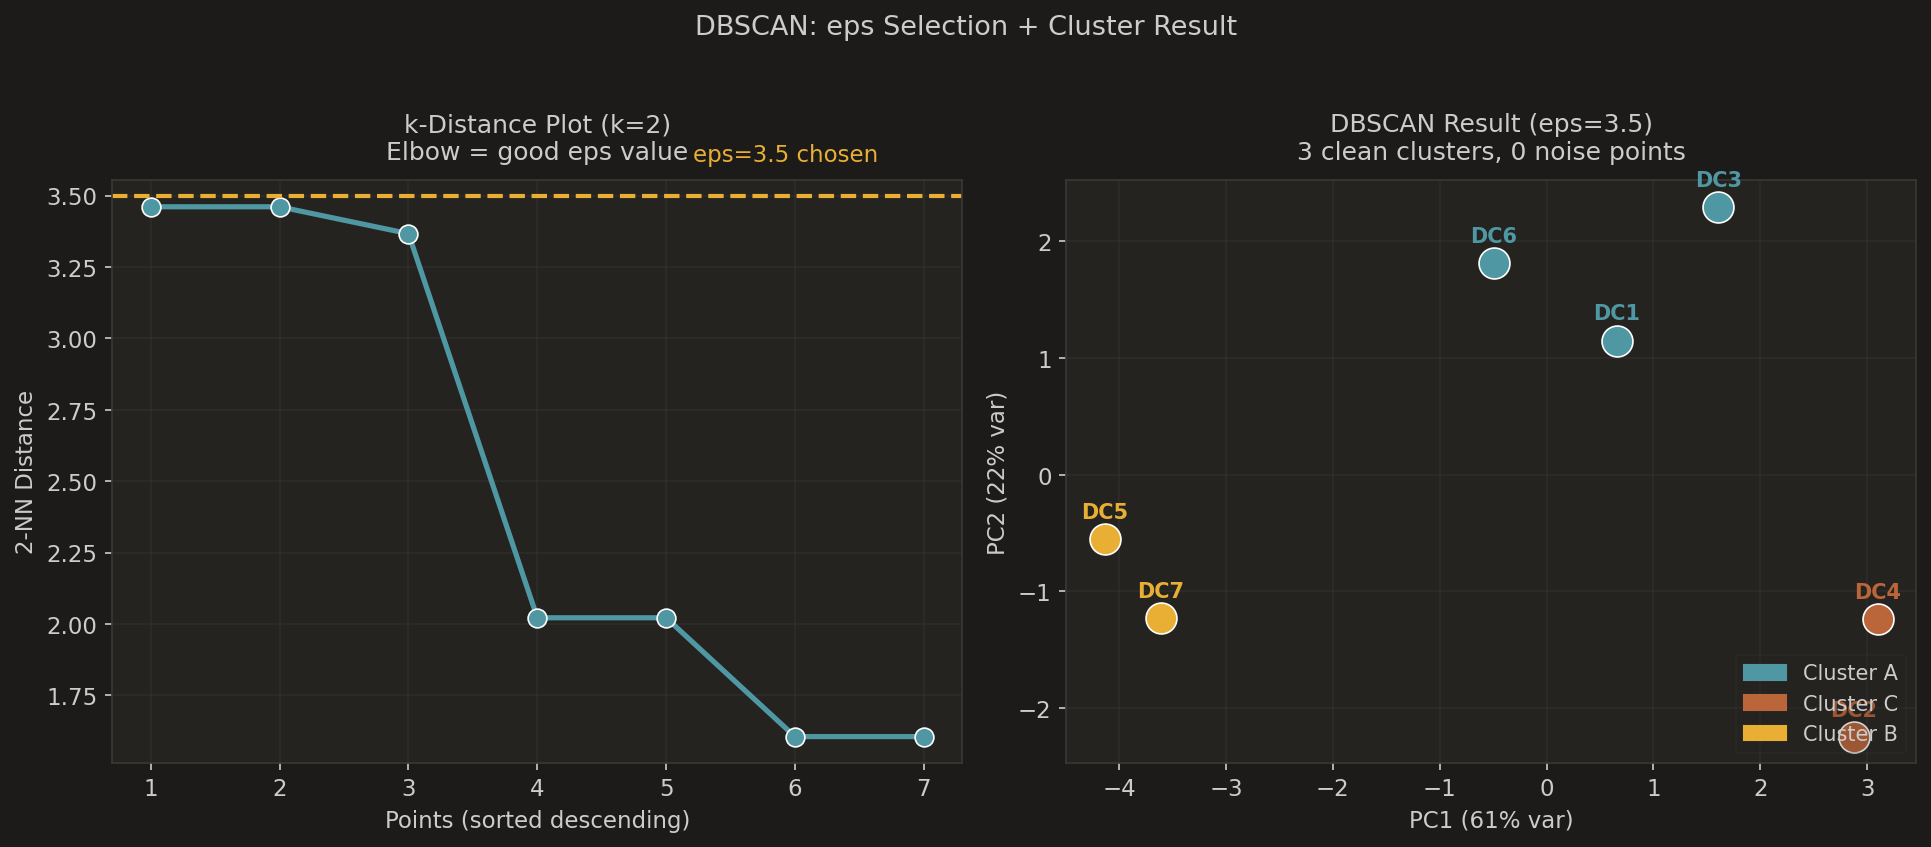

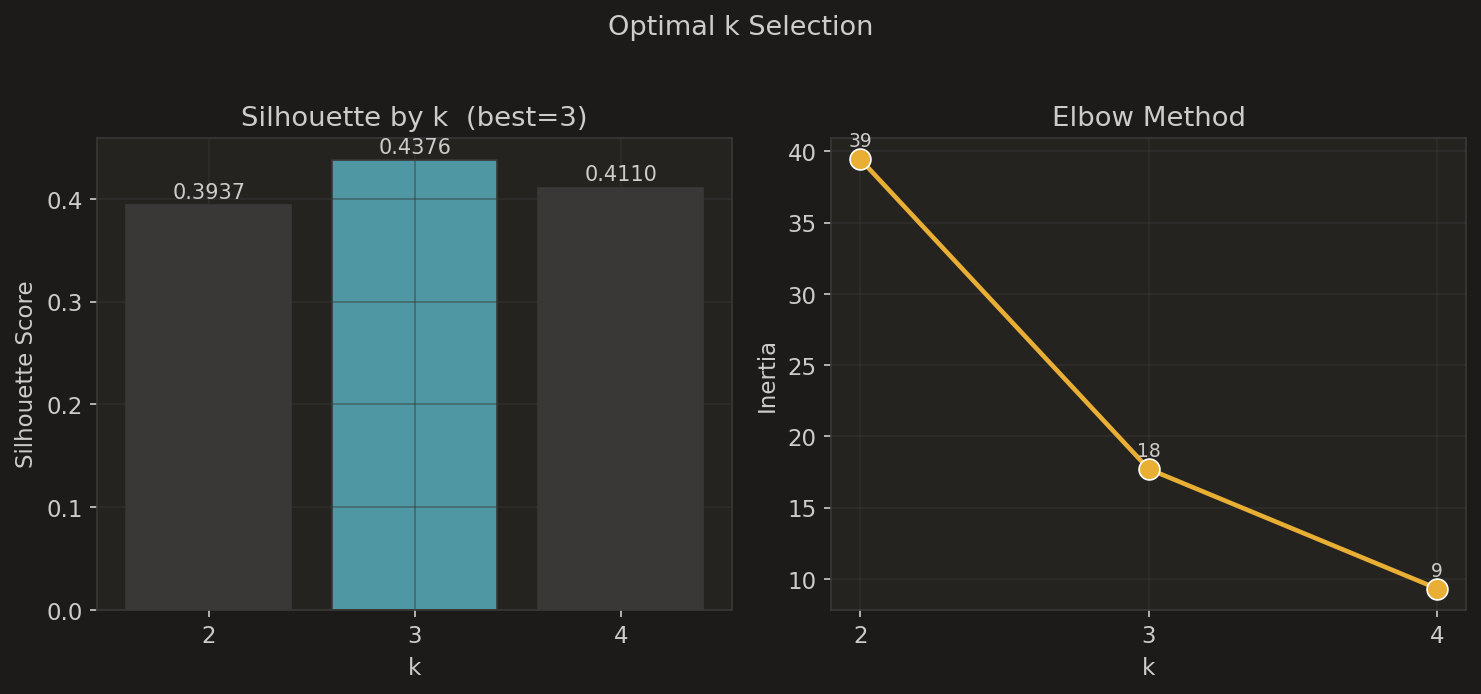

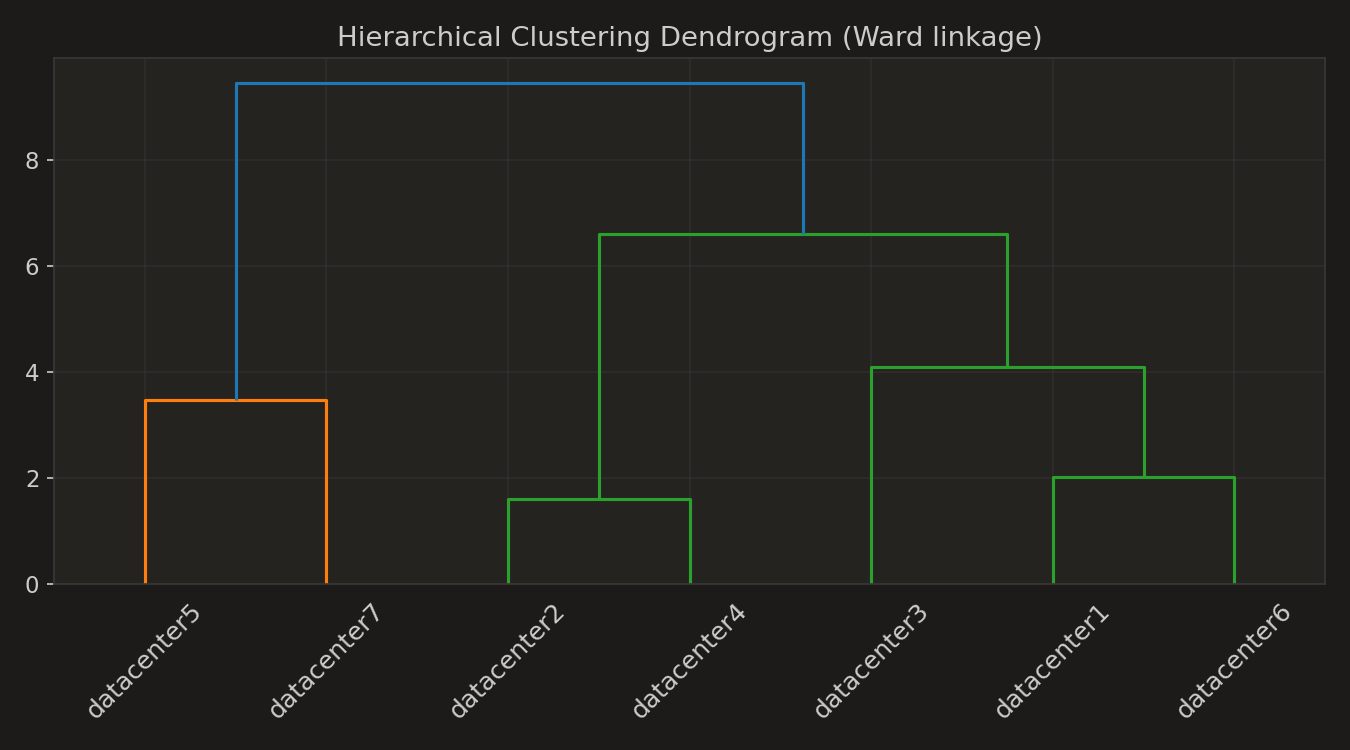

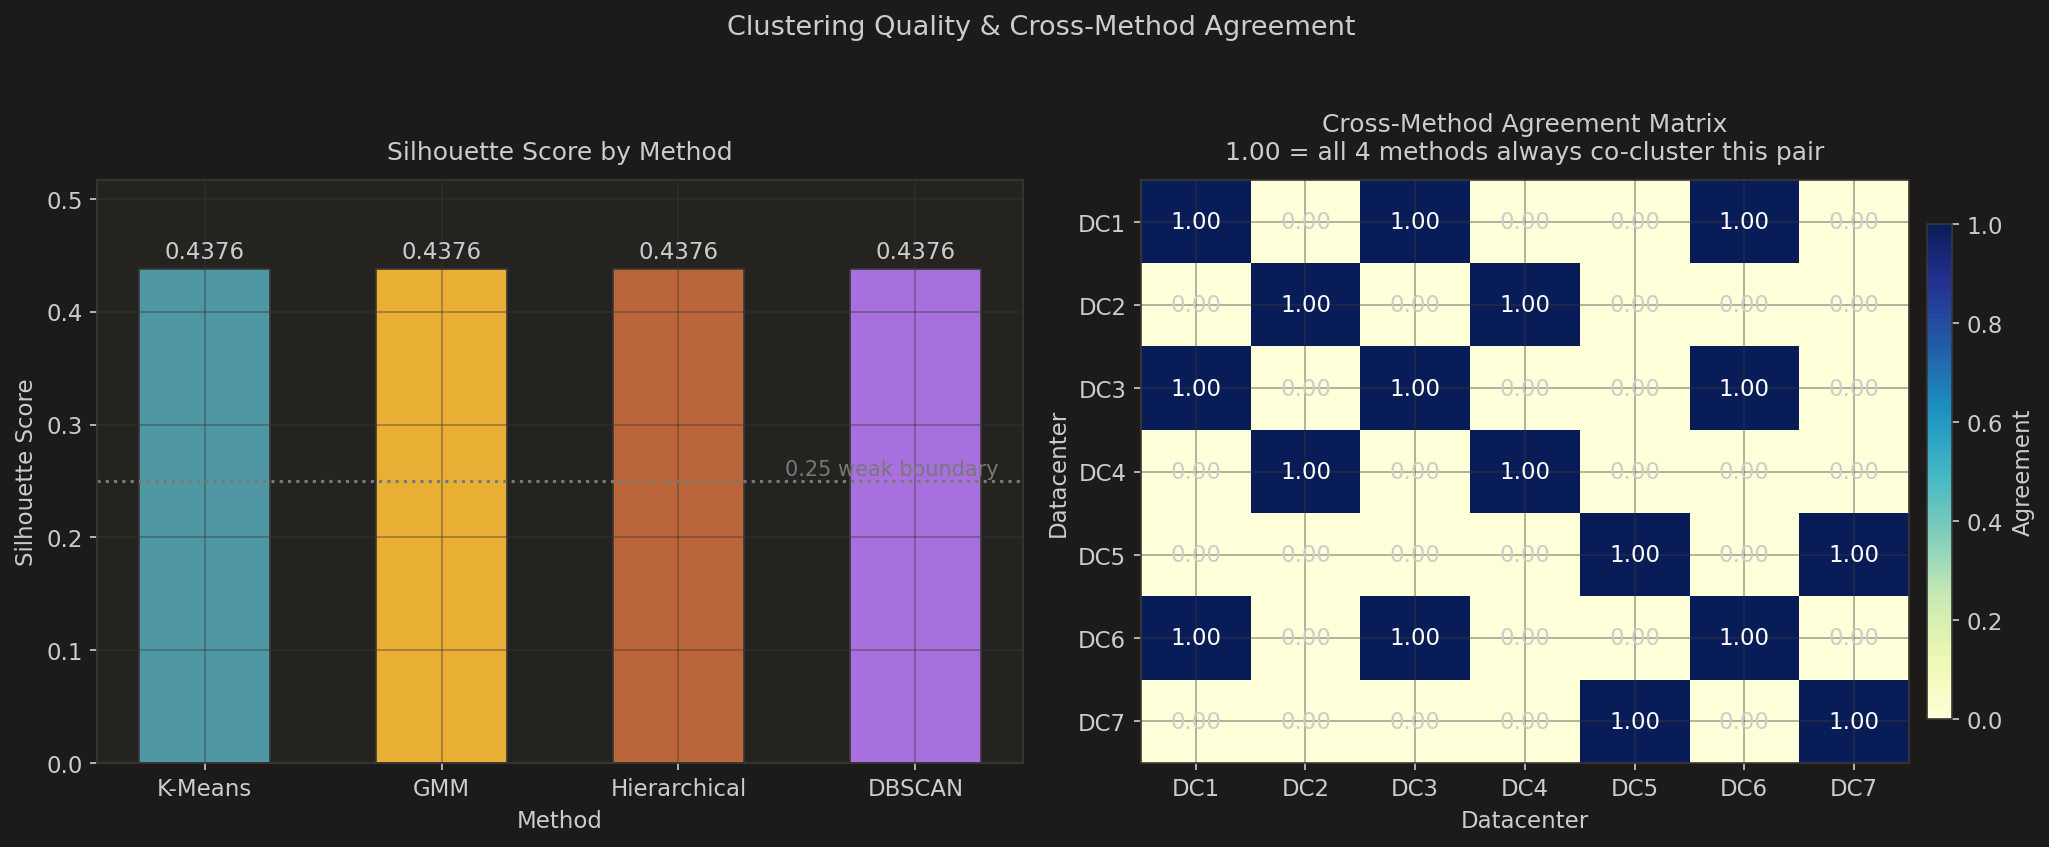

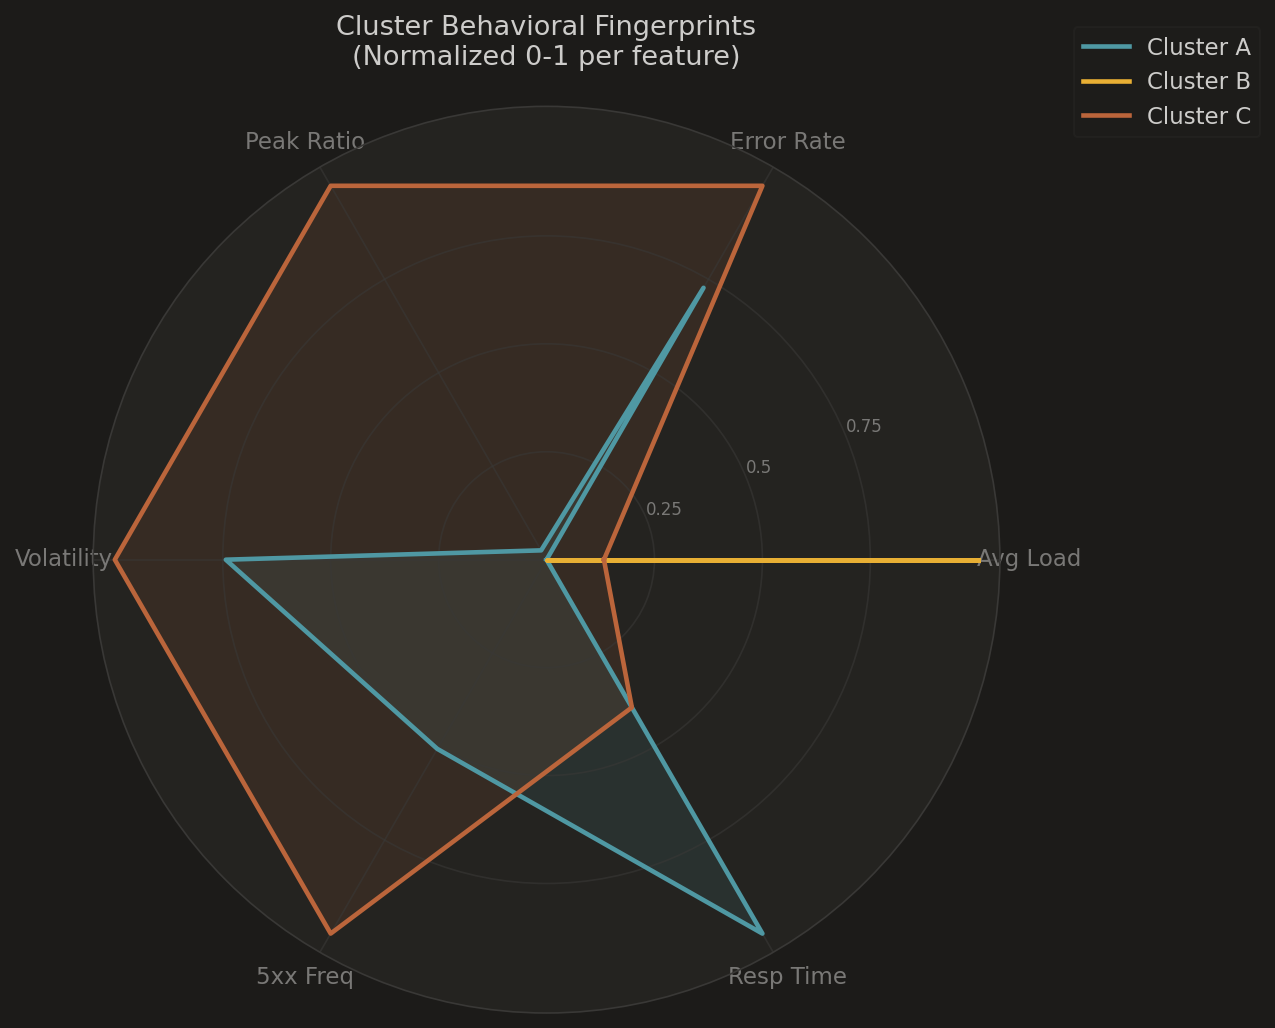

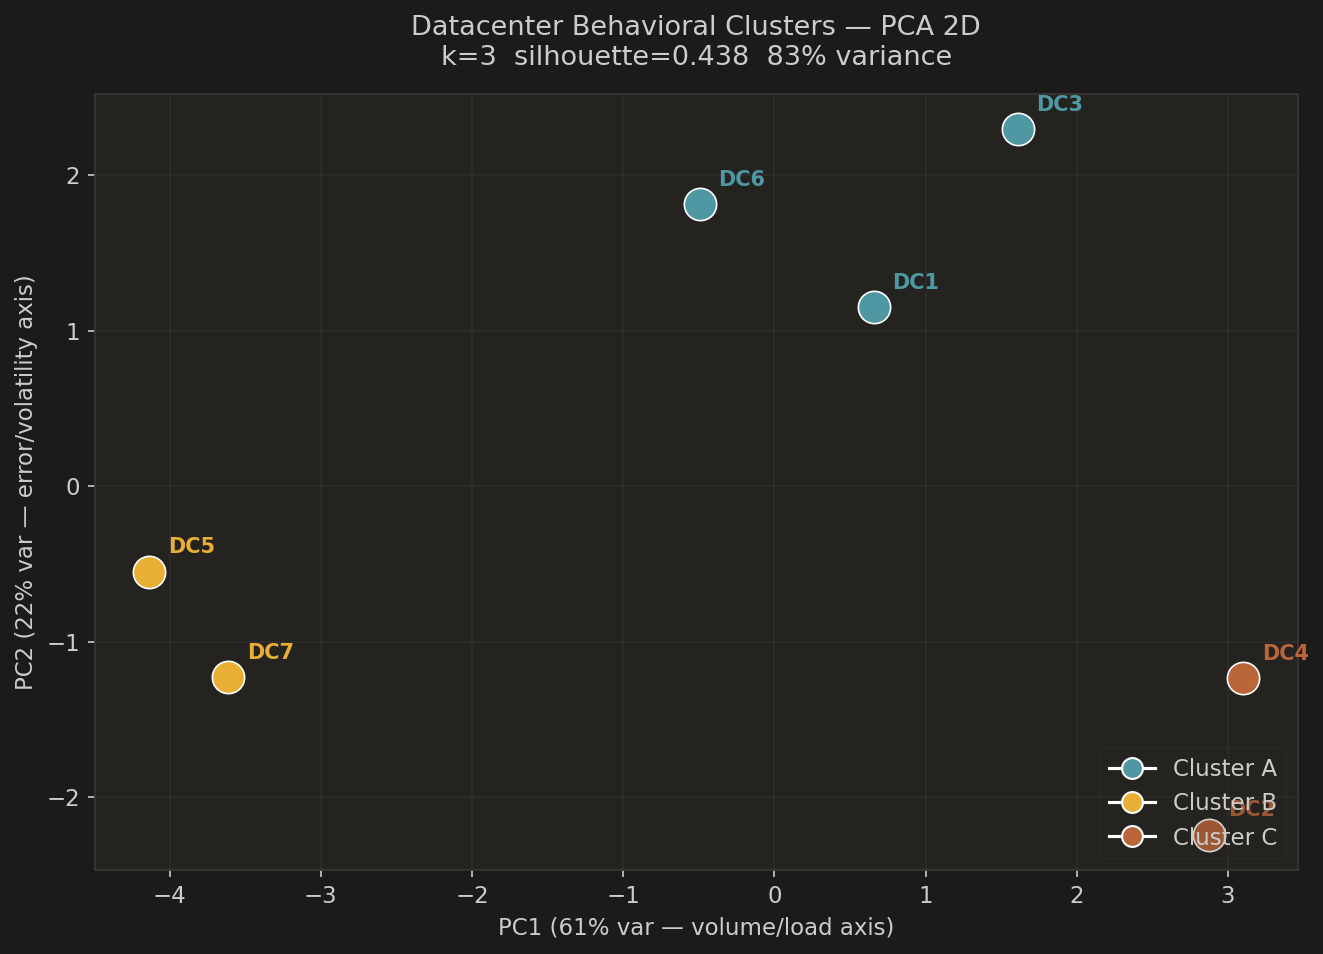

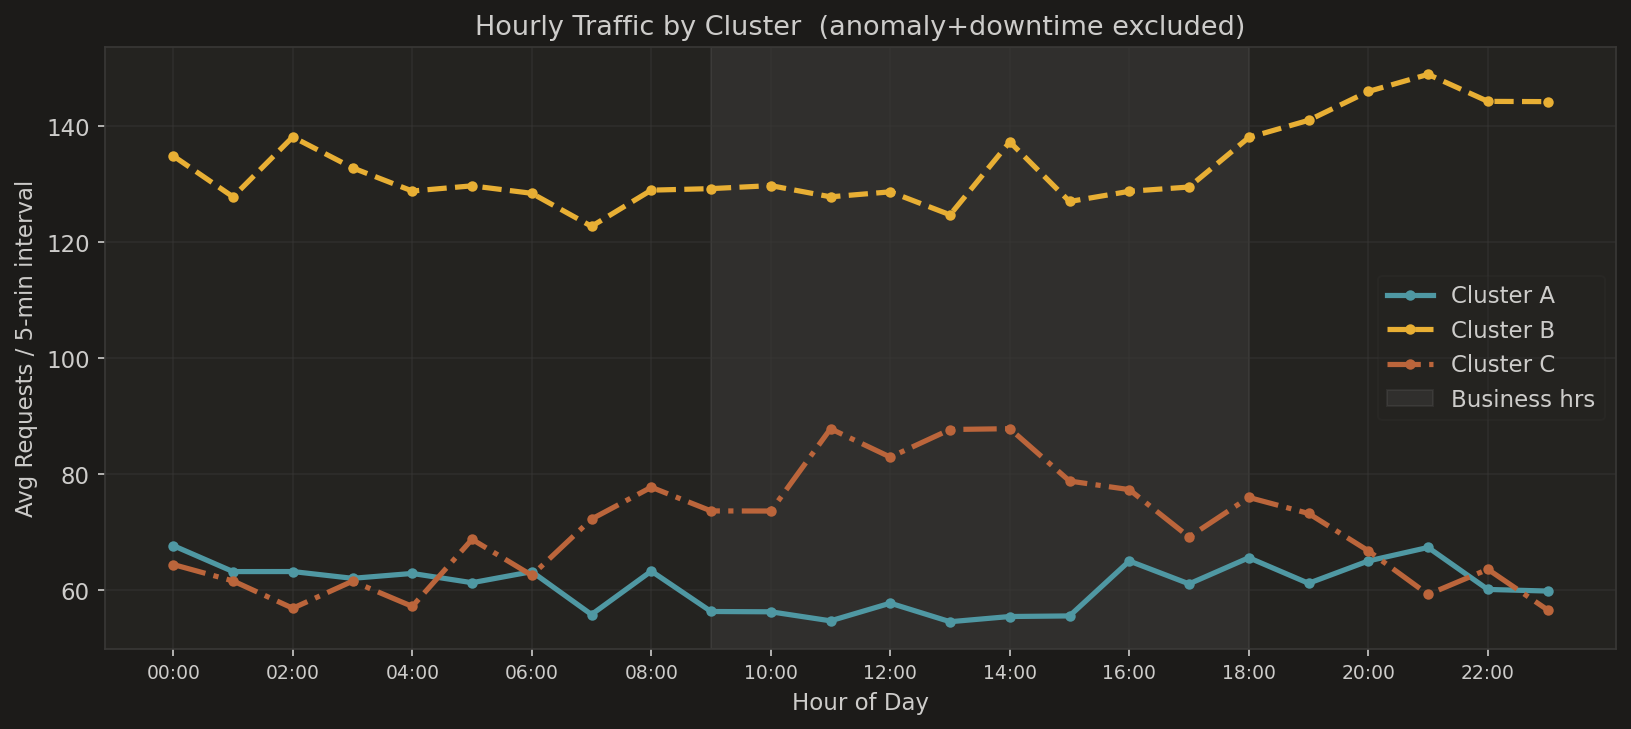

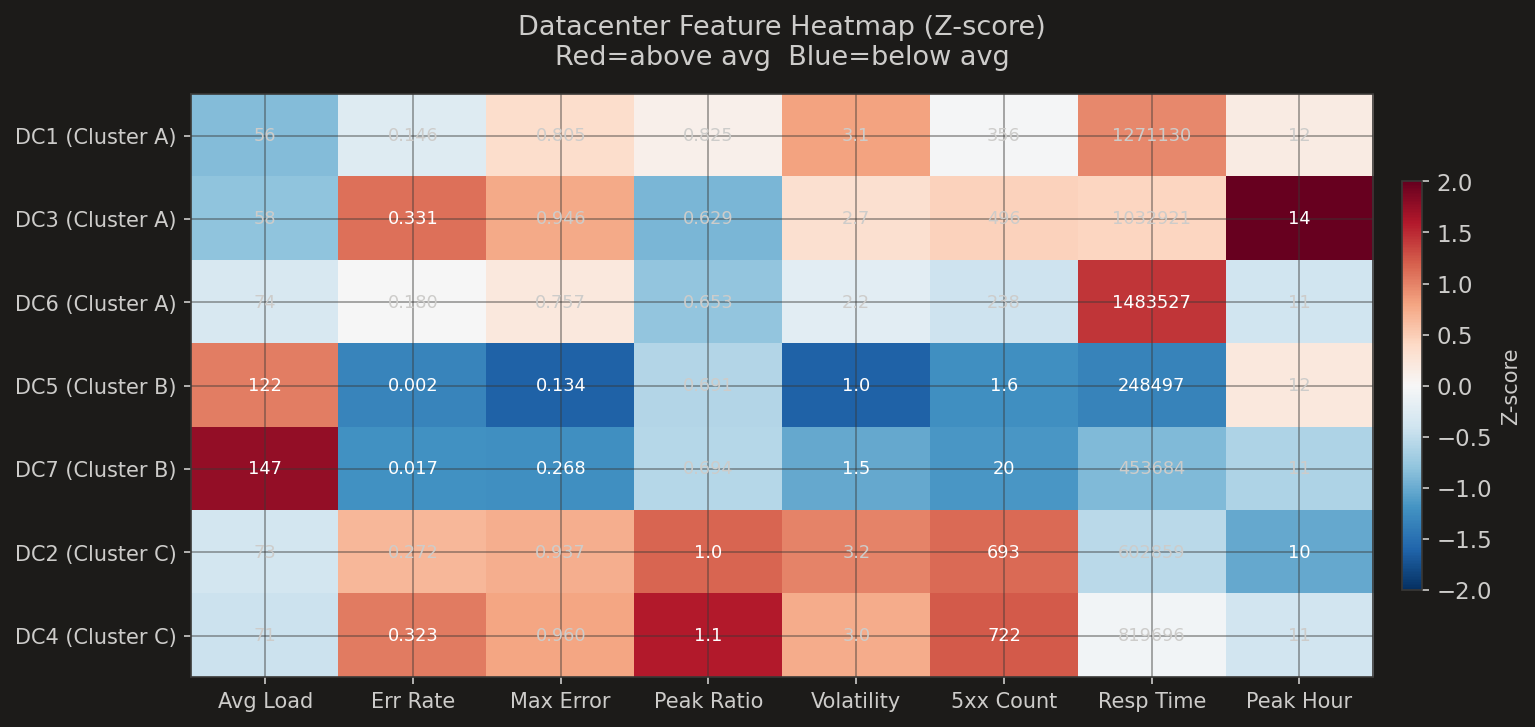

In [0]:
from IPython.display import Image, display
import glob

for img_path in glob.glob('/tmp/clustering_plots/*.png'):
    display(Image(filename=img_path))


### CONCLUSION

* The data captured had 413.241.248 rows that was pre-processed using Spark pipeline that transformed into a **966-row daily behavioral fingerprint** doing aggregation, engineering 12 features across four operational dimensions: traffic volume, error behavior, temporal patterns, and latency.  
Aslo Freature engineering was done to create key fetures like  `is_peak` to capture business-hours load ratios, and **filtering out anomaly and downtime days** before profiling so clusters reflect normal operational character, not failure states. 

* Transformed data was applied to K-Means with silhouette-guided. *k* selection identified **k=3 as the optimal partition** (silhouette=0.4376), cleanly separating the datacenters into three behaviorally distinct groups:

    - **Cluster A** (DC1, DC3, DC6) — Slow, chronically error-prone, low and unpredictable traffic
    - **Cluster B** (DC5, DC7) — High load, near-zero errors, fastest response times — the resilience benchmark
    - **Cluster C** (DC2, DC4) — Business-hours peaks, highest error rate (29.6%), error intensity 70× worse than Cluster B

* K-Means solution was subjected to validation using a multi-method with fundamentally different mathematical assumptions. **Gaussian Mixture Models** (full covariance) confirmed the assignments with 100% membership certainty (soft probabilities were all 0.000 or 1.000, indicating no ambiguity. **Agglomerative Hierarchical Clustering** produced an identical partition, with the dendrogram showing a natural merge gap at k=3 that independently justifies the choice. **DBSCAN** (eps=3.5) reproduced the same three groups with zero noise points, confirming no datacenter is a genuine outlier that should be excluded from clustering.

* The analysis demonstrates that IBM Cloud's 7 datacenters do not operate as a homogeneous infrastructure. They exhibit three distinct behavioral identities that persist across 138 days of normal operation. Cluster B's ability to carry double the traffic of Cluster A while maintaining 30× lower error rates is the central finding — it establishes a concrete, data-driven benchmark that makes the underperformance of Clusters A and C not just observable, but **measurable and actionable.